# 🫀 Unsupervised ECG Anomaly Detection using an LSTM Autoencoder


# Phase 1 - Setup

# 1. Setup and Configuration

In [1]:
# ==========================================================
# 1. Setup and Configuration
# ==========================================================

# Standard library
import os
import pickle
import random
import warnings
from pathlib import Path

# Scientific computing and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Paths
DATA_DIR = Path("/kaggle/input/datasets/yaekob/geo-ecg-dataset")
METADATA_PATH = DATA_DIR / "metadata.csv"
ECG_DATA_PATH = DATA_DIR / "org_dataset.pkl"
OUTPUT_ROOT = Path("/kaggle/working/outputs")

# Protocols to run: ["A"], ["B"], or ["A", "B"]
RUN_PROTOCOLS = ["A", "B"]

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Required files and output folders
missing_files = [
    path for path in (METADATA_PATH, ECG_DATA_PATH)
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Missing dataset files:\n"
        + "\n".join(map(str, missing_files))
    )

for protocol in RUN_PROTOCOLS:
    (OUTPUT_ROOT / f"protocol_{protocol}").mkdir(
        parents=True,
        exist_ok=True
    )

print(
    f"Device: {DEVICE} | "
    f"Seed: {RANDOM_SEED} | "
    f"Protocols: {', '.join(RUN_PROTOCOLS)}"
)

if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda | Seed: 42 | Protocols: A, B
GPU: Tesla T4


# 2. Load and Validate the Dataset

In [2]:
# ==========================================================
# 2. Load and Validate the Dataset
# ==========================================================

metadata_df = pd.read_csv(METADATA_PATH)

with open(ECG_DATA_PATH, "rb") as file:
    ecg_dataset = pickle.load(file)

# Required columns
metadata_required = {"ecg_id", "AF"}
signal_required = {"ecg_id", "segment_id", "ecg"}

missing_metadata = metadata_required - set(metadata_df.columns)
missing_signal = signal_required - set(ecg_dataset.columns)

if missing_metadata:
    raise KeyError(
        f"Missing metadata columns: {sorted(missing_metadata)}"
    )

if missing_signal:
    raise KeyError(
        f"Missing ECG-data columns: {sorted(missing_signal)}"
    )

# Metadata integrity
if metadata_df["ecg_id"].isna().any():
    raise ValueError("Missing ECG identifiers found in metadata.")

if metadata_df["ecg_id"].duplicated().any():
    raise ValueError("Duplicate ECG identifiers found in metadata.")

if not metadata_df["AF"].isin([0, 1]).all():
    raise ValueError("AF labels must contain only 0 and 1.")

metadata_df["AF"] = metadata_df["AF"].astype(np.int64)

# The principal target and binary AF column are related but
# are not required to be identical in this dataset.
target_af_mismatches = np.nan

if "target" in metadata_df.columns:
    target_af = metadata_df["target"].eq("AF").astype(np.int64)

    target_af_mismatches = int(
        target_af.ne(metadata_df["AF"]).sum()
    )

# ECG-data integrity
if ecg_dataset[["ecg_id", "segment_id", "ecg"]].isna().any().any():
    raise ValueError("Missing values found in the ECG dataset.")

if ecg_dataset.duplicated(["ecg_id", "segment_id"]).any():
    raise ValueError("Duplicate ECG segments found.")

metadata_ids = set(metadata_df["ecg_id"])
signal_ids = set(ecg_dataset["ecg_id"])

missing_signals = metadata_ids - signal_ids
unknown_signals = signal_ids - metadata_ids

if missing_signals:
    raise ValueError(
        f"{len(missing_signals)} metadata ECGs have no signal data."
    )

# Extra signal recordings are allowed. Only ECG IDs shared
# with metadata will be retained in the modeling dataset.
extra_signal_count = len(unknown_signals)

# Compact summary
class_counts = (
    metadata_df["AF"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

dataset_summary = pd.DataFrame(
    {
        "Value": [
            len(metadata_df),
            metadata_df.shape[1],
            ecg_dataset["ecg_id"].nunique(),
            len(ecg_dataset),
            int(class_counts[0]),
            int(class_counts[1]),
            int(metadata_df.isna().sum().sum()),
            (
                int(target_af_mismatches)
                if np.isfinite(target_af_mismatches)
                else "N/A"
            ),
        ]
    },
    index=[
        "Metadata recordings",
        "Metadata fields",
        "Signal recordings",
        "ECG segments",
        "Normal recordings",
        "AF recordings",
        "Missing metadata values",
        "Target/AF label differences",
    ],
)

display(dataset_summary)

print(
    f"Loaded {len(metadata_df):,} ECG recordings and "
    f"{len(ecg_dataset):,} signal segments: "
    f"{class_counts[0]:,} Normal and {class_counts[1]:,} AF."
)

if np.isfinite(target_af_mismatches) and target_af_mismatches > 0:
    print(
        f"Note: {target_af_mismatches:,} principal target labels differ "
        "from the binary AF column; the binary AF column is used for modeling."
    )

,Value
Metadata recordings,3000
Metadata fields,72
Signal recordings,10344
ECG segments,20636
Normal recordings,2492
AF recordings,508
Missing metadata values,0
Target/AF label differences,508


Loaded 3,000 ECG recordings and 20,636 signal segments: 2,492 Normal and 508 AF.
Note: 508 principal target labels differ from the binary AF column; the binary AF column is used for modeling.


# Phase 2 - Data Understanding

# 3. Validate ECG Signal Structure

In [3]:
# ==========================================================
# 3. Validate ECG Signal Structure
# ==========================================================
# Verify the signal format, dimensions, and numerical integrity.

required_signal_columns = {"ecg_id", "ecg"}
missing_columns = required_signal_columns - set(ecg_dataset.columns)

if missing_columns:
    raise KeyError(
        f"Missing ECG dataset columns: {sorted(missing_columns)}"
    )

sample_signal = ecg_dataset["ecg"].iloc[0]

if isinstance(sample_signal, torch.Tensor):
    sample_shape = tuple(sample_signal.shape)
elif isinstance(sample_signal, np.ndarray):
    sample_shape = sample_signal.shape
else:
    raise TypeError(
        f"Unsupported ECG signal type: {type(sample_signal).__name__}"
    )

# Check that every ECG segment has the same shape.
shape_counts = (
    ecg_dataset["ecg"]
    .map(lambda signal: tuple(signal.shape))
    .value_counts()
)

if len(shape_counts) != 1:
    raise ValueError(
        f"Inconsistent ECG shapes detected:\n{shape_counts}"
    )

EXPECTED_SIGNAL_SHAPE = (12, 2500)

if sample_shape != EXPECTED_SIGNAL_SHAPE:
    raise ValueError(
        f"Expected ECG shape {EXPECTED_SIGNAL_SHAPE}, "
        f"but found {sample_shape}."
    )

# Compute global statistics without stacking the full dataset.
global_min = float("inf")
global_max = float("-inf")
total_sum = total_squared_sum = 0.0
total_values = nan_count = inf_count = 0

for signal in ecg_dataset["ecg"]:
    tensor = (
        signal.detach().cpu()
        if isinstance(signal, torch.Tensor)
        else torch.as_tensor(signal)
    ).float()

    global_min = min(global_min, tensor.min().item())
    global_max = max(global_max, tensor.max().item())
    total_sum += tensor.sum().item()
    total_squared_sum += tensor.square().sum().item()
    total_values += tensor.numel()
    nan_count += torch.isnan(tensor).sum().item()
    inf_count += torch.isinf(tensor).sum().item()

if nan_count or inf_count:
    raise ValueError(
        f"Invalid ECG values detected: "
        f"{nan_count} NaN and {inf_count} Inf."
    )

global_mean = total_sum / total_values
global_variance = max(
    total_squared_sum / total_values - global_mean**2,
    0.0
)
global_std = global_variance**0.5

signal_summary = pd.DataFrame(
    {
        "Value": [
            len(ecg_dataset),
            str(sample_shape),
            total_values,
            global_min,
            global_max,
            global_mean,
            global_std,
            nan_count,
            inf_count,
        ]
    },
    index=[
        "ECG segments",
        "Segment shape",
        "Total signal values",
        "Minimum",
        "Maximum",
        "Mean",
        "Standard deviation",
        "NaN values",
        "Infinite values",
    ]
)

display(signal_summary)

print(
    f"Validated {len(ecg_dataset):,} ECG segments "
    f"with shape {sample_shape}."
)

,Value
ECG segments,20636
Segment shape,"(12, 2500)"
Total signal values,619080000
Minimum,-36.41608
Maximum,40.662651
Mean,0.0
Standard deviation,0.999964
NaN values,0
Infinite values,0


Validated 20,636 ECG segments with shape (12, 2500).


# 4. Validate Recording and Segment Structure

In [4]:
# ==========================================================
# 4. Validate Recording and Segment Structure
# ==========================================================
# Verify that every metadata ECG has signal data. Additional
# signal-only recordings are allowed and excluded later by
# the inner merge used to build the modeling dataset.

metadata_ids = set(metadata_df["ecg_id"])
signal_ids = set(ecg_dataset["ecg_id"])

metadata_only = metadata_ids - signal_ids
signal_only = signal_ids - metadata_ids
shared_ids = metadata_ids & signal_ids

# Every metadata recording used for modeling must have signals.
if metadata_only:
    raise ValueError(
        f"{len(metadata_only)} metadata ECGs have no signal data."
    )

# Validate one unique segment ID per ECG recording.
if ecg_dataset.duplicated(["ecg_id", "segment_id"]).any():
    raise ValueError(
        "Duplicate segment identifiers found within an ECG recording."
    )

# Summarize segment availability for the shared recordings only.
shared_signal_df = ecg_dataset.loc[
    ecg_dataset["ecg_id"].isin(shared_ids)
].copy()

segment_counts = shared_signal_df.groupby("ecg_id").size()

segment_distribution = (
    segment_counts
    .value_counts()
    .sort_index()
    .rename_axis("Segments per recording")
    .to_frame("Recordings")
)

incomplete_ecg_ids = segment_counts[segment_counts == 1].index

recording_summary = pd.DataFrame(
    {
        "Value": [
            len(metadata_ids),
            len(signal_ids),
            len(shared_ids),
            len(signal_only),
            len(shared_signal_df),
            int(segment_counts.min()),
            int(segment_counts.max()),
            float(segment_counts.mean()),
            len(incomplete_ecg_ids),
        ]
    },
    index=[
        "Metadata recordings",
        "Signal recordings",
        "Shared recordings used",
        "Extra signal-only recordings",
        "Shared ECG segments",
        "Minimum segments per recording",
        "Maximum segments per recording",
        "Average segments per recording",
        "One-segment recordings",
    ],
)

display(recording_summary)
display(segment_distribution)

print(
    f"Validated {len(shared_ids):,} shared ECG recordings; "
    f"{len(incomplete_ecg_ids):,} contain one segment."
)

if signal_only:
    print(
        f"Note: {len(signal_only):,} signal-only recordings will be "
        "excluded when the modeling dataset is created."
    )

,Value
Metadata recordings,3000.000000
Signal recordings,10344.000000
Shared recordings used,3000.000000
Extra signal-only recordings,7344.000000
Shared ECG segments,5983.000000
Minimum segments per recording,1.000000
Maximum segments per recording,2.000000
Average segments per recording,1.994333
One-segment recordings,17.000000


,Recordings
Segments per recording,
1,17
2,2983


Validated 3,000 shared ECG recordings; 17 contain one segment.
Note: 7,344 signal-only recordings will be excluded when the modeling dataset is created.


# 5. Visualize Representative Normal and AF ECG Segments

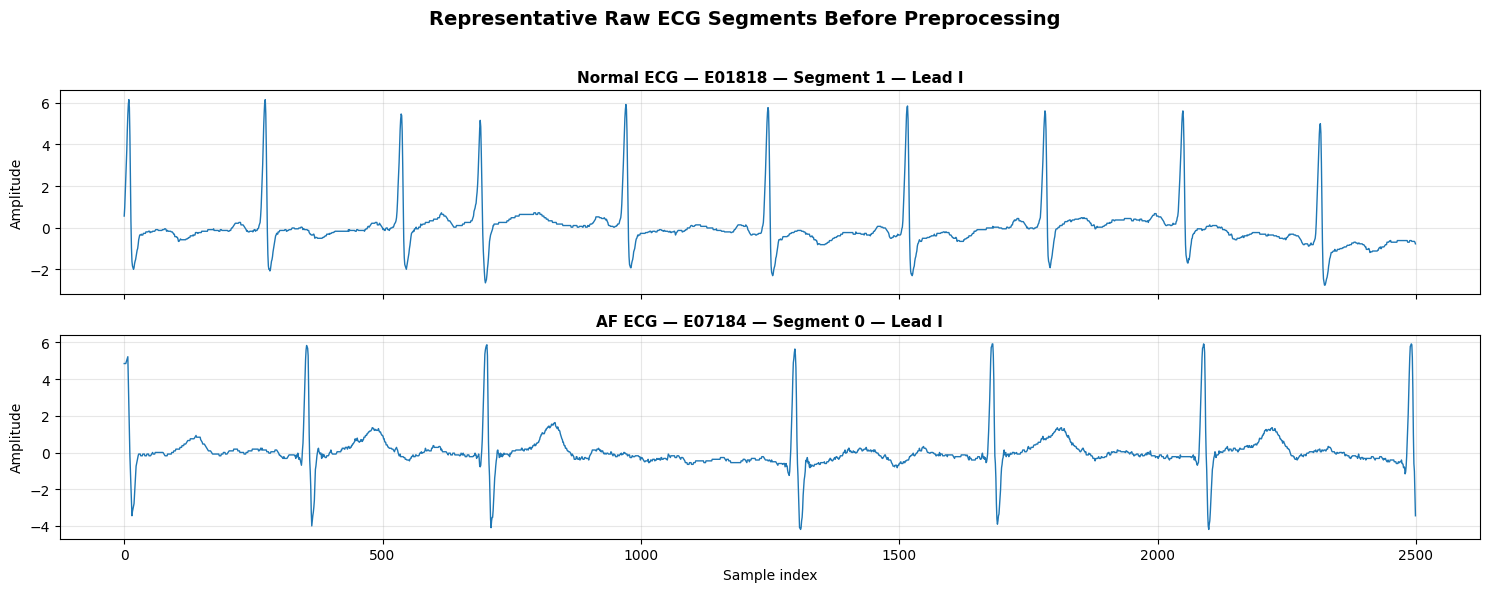

In [5]:
# ==========================================================
# 5. Visualize Representative Normal and AF ECG Segments
# ==========================================================
# Display one reproducibly selected raw segment from each class
# before preprocessing.

DISPLAY_LEAD = 0
DISPLAY_LEAD_NAME = "Lead I"


def select_representative_segment(af_label):
    """Select one raw ECG segment from the requested class."""
    eligible_ids = metadata_df.loc[
        metadata_df["AF"].eq(af_label),
        "ecg_id",
    ]

    candidates = ecg_dataset.loc[
        ecg_dataset["ecg_id"].isin(eligible_ids)
    ]

    if candidates.empty:
        raise ValueError(
            f"No ECG segments found for AF label {af_label}."
        )

    return candidates.sample(
        n=1,
        random_state=RANDOM_SEED,
    ).iloc[0]


def to_lead_major(signal):
    """Return a raw ECG array with shape (leads, samples)."""
    if isinstance(signal, torch.Tensor):
        signal = signal.detach().cpu().numpy()

    signal = np.asarray(signal)

    if signal.ndim != 2:
        raise ValueError(
            f"Expected a 2D ECG signal, received shape {signal.shape}."
        )

    # ECG segments are expected to have far fewer leads than samples.
    if signal.shape[0] > signal.shape[1]:
        signal = signal.T

    if not np.isfinite(signal).all():
        raise ValueError("ECG signal contains NaN or infinite values.")

    return signal


normal_sample = select_representative_segment(af_label=0)
af_sample = select_representative_segment(af_label=1)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 6),
    sharex=True,
)

for ax, sample, class_name in [
    (axes[0], normal_sample, "Normal"),
    (axes[1], af_sample, "AF"),
]:
    signal = to_lead_major(sample["ecg"])

    if DISPLAY_LEAD >= signal.shape[0]:
        raise IndexError(
            f"Lead index {DISPLAY_LEAD} is unavailable for "
            f"signal shape {signal.shape}."
        )

    ax.plot(
        signal[DISPLAY_LEAD],
        linewidth=1.0,
    )

    ax.set_title(
        f"{class_name} ECG — {sample['ecg_id']} — "
        f"Segment {sample['segment_id']} — {DISPLAY_LEAD_NAME}",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_ylabel("Amplitude")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Sample index")

fig.suptitle(
    "Representative Raw ECG Segments Before Preprocessing",
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Phase 3 - Data Preparation & Preprocessing

# 6. Construct the Modeling Dataset

In [6]:
# ==========================================================
# 6. Construct the Modeling Dataset
# ==========================================================
# Merge ECG segments with AF labels and verify the final
# recording-level dataset before protocol-specific splitting.

modeling_df = (
    ecg_dataset
    .merge(metadata_df[["ecg_id", "AF"]], on="ecg_id", how="inner")
    [["ecg_id", "segment_id", "ecg", "AF"]]
    .sort_values(["ecg_id", "segment_id"])
    .reset_index(drop=True)
)

# Integrity checks
if modeling_df.isna().any().any():
    raise ValueError("Missing values found in the modeling dataset.")

if modeling_df.duplicated(["ecg_id", "segment_id"]).any():
    raise ValueError("Duplicate ECG segments found.")

label_counts = modeling_df.groupby("ecg_id")["AF"].nunique()

if (label_counts > 1).any():
    raise ValueError("Inconsistent AF labels found within ECG recordings.")

# Compact dataset summary
recording_labels = modeling_df.groupby("ecg_id")["AF"].first()

modeling_summary = pd.DataFrame(
    {
        "ECG recordings": [recording_labels.size],
        "ECG segments": [len(modeling_df)],
        "Normal recordings": [(recording_labels == 0).sum()],
        "AF recordings": [(recording_labels == 1).sum()],
        "One-segment recordings": [(modeling_df.groupby("ecg_id").size() == 1).sum()],
        "Two-segment recordings": [(modeling_df.groupby("ecg_id").size() == 2).sum()],
    }
)

display(modeling_summary)

print(
    f"Modeling dataset ready: "
    f"{recording_labels.size:,} recordings and "
    f"{len(modeling_df):,} segments."
)

,ECG recordings,ECG segments,Normal recordings,AF recordings,One-segment recordings,Two-segment recordings
0,3000,5983,2492,508,17,2983


Modeling dataset ready: 3,000 recordings and 5,983 segments.


# 7. Create Protocol A and Protocol B Splits

In [7]:
# ==========================================================
# 7. Create Protocol A and Protocol B Splits
# ==========================================================
# Reserve shared, balanced validation and test sets, then
# construct protocol-specific training sets at recording level.

VALID_AF_RATIO = 0.15
TEST_AF_RATIO = 0.15
NORMAL_TO_AF_RATIO = 2.0

# One label per ECG recording
recording_labels = (
    modeling_df.groupby("ecg_id", as_index=False)["AF"].first()
)

normal_labels = (
    recording_labels.query("AF == 0")
    .reset_index(drop=True)
)

af_labels = (
    recording_labels.query("AF == 1")
    .reset_index(drop=True)
)

# Use equal class counts in validation and test
n_valid = round(VALID_AF_RATIO * len(af_labels))
n_test = round(TEST_AF_RATIO * len(af_labels))

if min(n_valid, n_test) <= 0:
    raise ValueError("Validation and test sets must be non-empty.")

# Create shared AF validation and test partitions
af_remaining, af_test = train_test_split(
    af_labels,
    test_size=n_test,
    random_state=RANDOM_SEED,
    shuffle=True,
)

af_train_pool, af_valid = train_test_split(
    af_remaining,
    test_size=n_valid,
    random_state=RANDOM_SEED,
    shuffle=True,
)

# Create shared Normal validation and test partitions
normal_remaining, normal_test = train_test_split(
    normal_labels,
    test_size=n_test,
    random_state=RANDOM_SEED,
    shuffle=True,
)

normal_train_pool, normal_valid = train_test_split(
    normal_remaining,
    test_size=n_valid,
    random_state=RANDOM_SEED,
    shuffle=True,
)

# Shared balanced evaluation sets
valid_labels = (
    pd.concat([normal_valid, af_valid], ignore_index=True)
    .sample(frac=1, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

test_labels = (
    pd.concat([normal_test, af_test], ignore_index=True)
    .sample(frac=1, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

# Protocol A: mixed training with Normal:AF = 2:1
n_normal_a = min(
    round(NORMAL_TO_AF_RATIO * len(af_train_pool)),
    len(normal_train_pool),
)

train_labels_a = (
    pd.concat(
        [
            normal_train_pool.sample(
                n=n_normal_a,
                random_state=RANDOM_SEED,
            ),
            af_train_pool,
        ],
        ignore_index=True,
    )
    .sample(frac=1, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

# Protocol B: all remaining Normal recordings only
train_labels_b = (
    normal_train_pool
    .sample(frac=1, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)


def select_recording_segments(labels_df):
    """Return every ECG segment belonging to selected recordings."""
    return (
        modeling_df[
            modeling_df["ecg_id"].isin(labels_df["ecg_id"])
        ]
        .copy()
        .reset_index(drop=True)
    )


def validate_split(train_labels, valid_labels, test_labels, protocol):
    """Verify protocol composition and recording-level separation."""
    train_ids = set(train_labels["ecg_id"])
    valid_ids = set(valid_labels["ecg_id"])
    test_ids = set(test_labels["ecg_id"])

    if train_ids & valid_ids or train_ids & test_ids or valid_ids & test_ids:
        raise ValueError(f"Data leakage detected in Protocol {protocol}.")

    valid_counts = valid_labels["AF"].value_counts()
    test_counts = test_labels["AF"].value_counts()

    if valid_counts.get(0, 0) != valid_counts.get(1, 0):
        raise ValueError("Validation set is not balanced.")

    if test_counts.get(0, 0) != test_counts.get(1, 0):
        raise ValueError("Test set is not balanced.")

    train_af = int(train_labels["AF"].sum())

    if protocol == "A" and train_af == 0:
        raise ValueError("Protocol A must include AF recordings.")

    if protocol == "B" and train_af != 0:
        raise ValueError("Protocol B must contain only Normal recordings.")


# Store all protocol-specific data in one dictionary
protocol_data = {}

for protocol, train_labels in {
    "A": train_labels_a,
    "B": train_labels_b,
}.items():

    validate_split(
        train_labels,
        valid_labels,
        test_labels,
        protocol,
    )

    protocol_data[protocol] = {
        "train_labels": train_labels,
        "valid_labels": valid_labels.copy(),
        "test_labels": test_labels.copy(),
        "train_df": select_recording_segments(train_labels),
        "valid_df": select_recording_segments(valid_labels),
        "test_df": select_recording_segments(test_labels),
    }


# Compact split summary
summary_rows = []

for protocol, data in protocol_data.items():
    for split in ("train", "valid", "test"):
        labels = data[f"{split}_labels"]
        segments = data[f"{split}_df"]

        normal_count = int((labels["AF"] == 0).sum())
        af_count = int((labels["AF"] == 1).sum())

        summary_rows.append({
            "Protocol": protocol,
            "Split": split.capitalize(),
            "Recordings": len(labels),
            "Normal": normal_count,
            "AF": af_count,
            "Segments": len(segments),
            "AF ratio (%)": 100 * af_count / len(labels),
        })

split_summary = pd.DataFrame(summary_rows)

display(split_summary.round(2))

print(
    "Protocol splits created successfully. "
    "Validation and test recordings are shared and balanced."
)

,Protocol,Split,Recordings,Normal,AF,Segments,AF ratio (%)
0,A,Train,1068,712,356,2129,33.33
1,A,Valid,152,76,76,304,50.00
2,A,Test,152,76,76,303,50.00
3,B,Train,2340,2340,0,4665,0.00
4,B,Valid,152,76,76,304,50.00
5,B,Test,152,76,76,303,50.00


Protocol splits created successfully. Validation and test recordings are shared and balanced.


# 8. Normalize ECG Signals and Create LSTM Windows

In [8]:
# ==========================================================
# 8. Normalize ECG Signals and Create LSTM Windows
# ==========================================================
# Fit lead-wise normalization on each protocol's training set,
# then apply it to its training, validation, and test signals.

WINDOW_LENGTH = 250
WINDOW_STRIDE = 125
N_LEADS = 12
NORMALIZATION_EPS = 1e-6

LEAD_NAMES = [
    "I", "II", "III", "aVR", "aVL", "aVF",
    "V1", "V2", "V3", "V4", "V5", "V6",
]


def to_time_major(signal):
    """Return a contiguous float32 ECG with shape (time, leads)."""
    if isinstance(signal, torch.Tensor):
        signal = signal.detach().cpu().numpy()

    signal = np.asarray(signal, dtype=np.float32)

    if signal.ndim != 2:
        raise ValueError(f"Expected a 2D ECG, found {signal.shape}.")

    if signal.shape[0] == N_LEADS:
        signal = signal.T
    elif signal.shape[1] != N_LEADS:
        raise ValueError(f"Cannot identify lead dimension in {signal.shape}.")

    if not np.isfinite(signal).all():
        raise ValueError("ECG contains NaN or infinite values.")

    return np.ascontiguousarray(signal)


def fit_normalization(dataframe):
    """Compute lead-wise mean and standard deviation from training ECGs."""
    count = 0
    total = np.zeros(N_LEADS, dtype=np.float64)
    squared_total = np.zeros(N_LEADS, dtype=np.float64)

    for signal in dataframe["ecg"]:
        signal = to_time_major(signal).astype(np.float64, copy=False)
        count += len(signal)
        total += signal.sum(axis=0)
        squared_total += np.square(signal).sum(axis=0)

    if count == 0:
        raise ValueError("Training split is empty.")

    mean = total / count
    variance = np.maximum(squared_total / count - mean**2, 0.0)
    std = np.maximum(np.sqrt(variance), NORMALIZATION_EPS)

    return mean.astype(np.float32), std.astype(np.float32), count


def create_windows(signal, mean, std):
    """Normalize one segment and divide it into overlapping windows."""
    signal = (to_time_major(signal) - mean) / std
    signal = signal.astype(np.float32, copy=False)

    if len(signal) < WINDOW_LENGTH:
        raise ValueError(
            f"Signal length {len(signal)} is shorter than "
            f"window length {WINDOW_LENGTH}."
        )

    windows = []

    for window_id, start in enumerate(
        range(0, len(signal) - WINDOW_LENGTH + 1, WINDOW_STRIDE)
    ):
        end = start + WINDOW_LENGTH

        windows.append(
            (
                window_id,
                start,
                end,
                np.ascontiguousarray(signal[start:end]),
            )
        )

    return windows


def prepare_windows(dataframe, mean, std):
    """Create one metadata-preserving row per ECG window."""
    rows = []

    for row in dataframe.itertuples(index=False):
        for window_id, start, end, window in create_windows(
            row.ecg, mean, std
        ):
            rows.append({
                "ecg_id": row.ecg_id,
                "segment_id": row.segment_id,
                "AF": int(row.AF),
                "window_id": window_id,
                "start_sample": start,
                "end_sample": end,
                "ecg": window,
            })

    result = pd.DataFrame(rows)

    if result.empty:
        raise ValueError("Window preparation produced no samples.")

    return result


# Prepare normalization statistics and windows independently per protocol
window_summary_rows = []

for protocol in RUN_PROTOCOLS:
    data = protocol_data[protocol]

    mean, std, timestep_count = fit_normalization(data["train_df"])

    data["normalization_mean"] = mean
    data["normalization_std"] = std
    data["normalization_timesteps"] = timestep_count

    for split in ("train", "valid", "test"):
        window_df = prepare_windows(
            data[f"{split}_df"],
            mean,
            std,
        )

        data[f"{split}_lstm_df"] = window_df

        # Verify that windowing preserved the recording split
        expected_ids = set(data[f"{split}_labels"]["ecg_id"])
        observed_ids = set(window_df["ecg_id"])

        if expected_ids != observed_ids:
            raise ValueError(
                f"Protocol {protocol} {split} window IDs do not match "
                "the recording-level split."
            )

        first_window = window_df.iloc[0]["ecg"]

        if first_window.shape != (WINDOW_LENGTH, N_LEADS):
            raise ValueError("Unexpected ECG window shape.")

        window_summary_rows.append({
            "Protocol": protocol,
            "Split": split.capitalize(),
            "Recordings": window_df["ecg_id"].nunique(),
            "Segments": window_df[
                ["ecg_id", "segment_id"]
            ].drop_duplicates().shape[0],
            "Windows": len(window_df),
            "Window shape": str(first_window.shape),
        })


window_summary = pd.DataFrame(window_summary_rows)
display(window_summary)

print(
    f"Prepared ECG windows of shape "
    f"({WINDOW_LENGTH}, {N_LEADS}) for "
    f"{len(RUN_PROTOCOLS)} protocol(s)."
)

,Protocol,Split,Recordings,Segments,Windows,Window shape
0,A,Train,1068,2129,40451,"(250, 12)"
1,A,Valid,152,304,5776,"(250, 12)"
2,A,Test,152,303,5757,"(250, 12)"
3,B,Train,2340,4665,88635,"(250, 12)"
4,B,Valid,152,304,5776,"(250, 12)"
5,B,Test,152,303,5757,"(250, 12)"


Prepared ECG windows of shape (250, 12) for 2 protocol(s).


# 9. Build PyTorch Datasets and DataLoaders

In [9]:
# ==========================================================
# 9. Build PyTorch Datasets and DataLoaders
# ==========================================================
# Convert normalized ECG windows into reproducible PyTorch
# datasets and loaders for both experimental protocols.

BATCH_SIZE = 64
NUM_WORKERS = 0
PIN_MEMORY = DEVICE.type == "cuda"


class ECGWindowDataset(Dataset):
    """Dataset of normalized ECG windows and evaluation metadata."""

    REQUIRED_COLUMNS = {
        "ecg_id",
        "segment_id",
        "AF",
        "window_id",
        "start_sample",
        "end_sample",
        "ecg",
    }

    def __init__(self, dataframe, split_name):
        missing = self.REQUIRED_COLUMNS - set(dataframe.columns)

        if missing:
            raise KeyError(
                f"{split_name} is missing columns: {sorted(missing)}"
            )

        if dataframe.empty:
            raise ValueError(f"{split_name} is empty.")

        self.split_name = split_name
        self.ecgs = dataframe["ecg"].to_numpy()
        self.labels = dataframe["AF"].to_numpy(dtype=np.int64)
        self.ecg_ids = dataframe["ecg_id"].astype(str).to_numpy()
        self.segment_ids = dataframe["segment_id"].to_numpy()
        self.window_ids = dataframe["window_id"].to_numpy(dtype=np.int64)
        self.starts = dataframe["start_sample"].to_numpy(dtype=np.int64)
        self.ends = dataframe["end_sample"].to_numpy(dtype=np.int64)

    def __len__(self):
        return len(self.ecgs)

    def __getitem__(self, index):
        signal = np.asarray(self.ecgs[index], dtype=np.float32)

        if signal.shape != (WINDOW_LENGTH, N_LEADS):
            raise ValueError(
                f"{self.split_name} item {index} has shape "
                f"{signal.shape}; expected "
                f"({WINDOW_LENGTH}, {N_LEADS})."
            )

        if not np.isfinite(signal).all():
            raise ValueError(
                f"{self.split_name} item {index} contains NaN or Inf."
            )

        return {
            "ecg": torch.from_numpy(np.ascontiguousarray(signal)),
            "label": torch.tensor(self.labels[index], dtype=torch.long),
            "ecg_id": self.ecg_ids[index],
            "segment_id": self.segment_ids[index],
            "window_id": torch.tensor(
                self.window_ids[index], dtype=torch.long
            ),
            "start_sample": torch.tensor(
                self.starts[index], dtype=torch.long
            ),
            "end_sample": torch.tensor(
                self.ends[index], dtype=torch.long
            ),
        }


def seed_worker(worker_id):
    """Seed optional DataLoader workers reproducibly."""
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def build_loader(dataset, shuffle, seed):
    """Create one reproducible PyTorch DataLoader."""
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
        worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
        persistent_workers=NUM_WORKERS > 0,
        generator=generator if shuffle else None,
    )


summary_rows = []

for protocol_index, protocol in enumerate(RUN_PROTOCOLS):
    data = protocol_data[protocol]

    for split in ("train", "valid", "test"):
        dataset = ECGWindowDataset(
            data[f"{split}_lstm_df"],
            split_name=f"Protocol {protocol} {split}",
        )

        loader = build_loader(
            dataset,
            shuffle=(split == "train"),
            seed=RANDOM_SEED + protocol_index,
        )

        data[f"{split}_dataset"] = dataset
        data[f"{split}_loader"] = loader

        summary_rows.append({
            "Protocol": protocol,
            "Split": split.capitalize(),
            "Windows": len(dataset),
            "Batches": len(loader),
            "Batch size": BATCH_SIZE,
        })

    # Verify protocol-specific training composition.
    training_labels = set(
        data["train_dataset"].labels.tolist()
    )

    if protocol == "A" and training_labels != {0, 1}:
        raise ValueError(
            "Protocol A training data must contain Normal and AF windows."
        )

    if protocol == "B" and training_labels != {0}:
        raise ValueError(
            "Protocol B training data must contain only Normal windows."
        )

    # Verify one training batch.
    batch = next(iter(data["train_loader"]))

    if tuple(batch["ecg"].shape[1:]) != (
        WINDOW_LENGTH,
        N_LEADS,
    ):
        raise ValueError(
            f"Protocol {protocol} has an invalid batch shape."
        )

    if batch["ecg"].dtype != torch.float32:
        raise TypeError(
            f"Protocol {protocol} ECG batch must use float32."
        )


loader_summary = pd.DataFrame(summary_rows)
display(loader_summary)

print(
    f"DataLoaders ready for Protocols "
    f"{', '.join(RUN_PROTOCOLS)} | "
    f"Batch size: {BATCH_SIZE}"
)

,Protocol,Split,Windows,Batches,Batch size
0,A,Train,40451,633,64
1,A,Valid,5776,91,64
2,A,Test,5757,90,64
3,B,Train,88635,1385,64
4,B,Valid,5776,91,64
5,B,Test,5757,90,64


DataLoaders ready for Protocols A, B | Batch size: 64


# Phase 4 - Model Design

# 10. Define and Verify the LSTM Autoencoder

In [10]:
# ==========================================================
# 10. Define and Verify the LSTM Autoencoder
# ==========================================================
# Compress each ECG window into a latent vector and reconstruct
# the complete sequence. AF labels are not used by the model
# or reconstruction loss.

# Model configuration
INPUT_SIZE = N_LEADS
HIDDEN_SIZE = 128
LATENT_SIZE = 64
DROPOUT = 0.20

SMOOTH_L1_BETA = 0.5
GRADIENT_CLIP_NORM = 1.0
MIN_RECONSTRUCTION_STD_RATIO = 0.05


class LSTMEncoder(nn.Module):
    """Encode an ECG window into a compact latent vector."""

    def __init__(
        self,
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        latent_size=LATENT_SIZE,
        dropout=DROPOUT,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
        )

        self.to_latent = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, latent_size),
            nn.Tanh(),
        )

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        return self.to_latent(hidden[-1])


class LSTMDecoder(nn.Module):
    """Reconstruct an ECG window from its latent vector."""

    def __init__(
        self,
        latent_size=LATENT_SIZE,
        hidden_size=HIDDEN_SIZE,
        output_size=INPUT_SIZE,
        sequence_length=WINDOW_LENGTH,
        dropout=DROPOUT,
    ):
        super().__init__()

        self.sequence_length = sequence_length

        self.from_latent = nn.Sequential(
            nn.Linear(latent_size, hidden_size),
            nn.Tanh(),
        )

        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True,
        )

        self.output_layer = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, latent):
        decoder_seed = self.from_latent(latent)

        # Repeat the latent-derived seed across all time steps.
        decoder_input = decoder_seed.unsqueeze(1).expand(
            -1,
            self.sequence_length,
            -1,
        )

        initial_hidden = decoder_seed.unsqueeze(0)
        initial_cell = torch.zeros_like(initial_hidden)

        decoded, _ = self.lstm(
            decoder_input,
            (initial_hidden, initial_cell),
        )

        return self.output_layer(decoded)


class LSTMAutoencoder(nn.Module):
    """End-to-end LSTM model for ECG-window reconstruction."""

    def __init__(self):
        super().__init__()
        self.encoder = LSTMEncoder()
        self.decoder = LSTMDecoder()

    def forward(self, x, return_latent=False):
        if x.ndim != 3:
            raise ValueError(
                "Expected input shape (batch, sequence, leads), "
                f"received {tuple(x.shape)}."
            )

        if tuple(x.shape[1:]) != (WINDOW_LENGTH, INPUT_SIZE):
            raise ValueError(
                f"Expected window shape ({WINDOW_LENGTH}, {INPUT_SIZE}), "
                f"received {tuple(x.shape[1:])}."
            )

        latent = self.encoder(x)
        reconstruction = self.decoder(latent)

        if reconstruction.shape != x.shape:
            raise RuntimeError(
                f"Input shape {tuple(x.shape)} and reconstruction shape "
                f"{tuple(reconstruction.shape)} do not match."
            )

        if return_latent:
            return reconstruction, latent

        return reconstruction


def build_model():
    """Create a fresh autoencoder on the selected device."""
    return LSTMAutoencoder().to(DEVICE)


def count_trainable_parameters(model):
    """Count parameters updated during optimization."""
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


# ----------------------------------------------------------
# End-to-end model verification
# ----------------------------------------------------------

verification_protocol = RUN_PROTOCOLS[0]
verification_loader = protocol_data[verification_protocol]["train_loader"]

sample_batch = next(iter(verification_loader))
sample_ecg = sample_batch["ecg"].to(
    DEVICE,
    dtype=torch.float32,
    non_blocking=True,
)

verification_model = build_model()
verification_loss = nn.SmoothL1Loss(beta=SMOOTH_L1_BETA)

# Verify the forward pass.
verification_model.eval()

with torch.inference_mode():
    reconstructed, latent = verification_model(
        sample_ecg,
        return_latent=True,
    )

    initial_loss = verification_loss(
        reconstructed,
        sample_ecg,
    )

expected_latent_shape = (
    sample_ecg.shape[0],
    LATENT_SIZE,
)

if reconstructed.shape != sample_ecg.shape:
    raise RuntimeError("The reconstruction shape is invalid.")

if latent.shape != expected_latent_shape:
    raise RuntimeError(
        f"Expected latent shape {expected_latent_shape}, "
        f"received {tuple(latent.shape)}."
    )

if not torch.isfinite(reconstructed).all():
    raise RuntimeError("The reconstruction contains NaN or Inf values.")

if not torch.isfinite(latent).all():
    raise RuntimeError("The latent representation contains NaN or Inf values.")

if not torch.isfinite(initial_loss):
    raise RuntimeError("The initial reconstruction loss is not finite.")


# Verify backward propagation and gradient clipping.
verification_model.train()
verification_model.zero_grad(set_to_none=True)

training_reconstruction = verification_model(sample_ecg)
training_loss = verification_loss(
    training_reconstruction,
    sample_ecg,
)

training_loss.backward()

encoder_gradients = [
    parameter.grad
    for parameter in verification_model.encoder.parameters()
    if parameter.grad is not None
]

decoder_gradients = [
    parameter.grad
    for parameter in verification_model.decoder.parameters()
    if parameter.grad is not None
]

if not encoder_gradients or not decoder_gradients:
    raise RuntimeError(
        "Gradients did not reach both the encoder and decoder."
    )

if not all(torch.isfinite(gradient).all() for gradient in encoder_gradients):
    raise RuntimeError("The encoder contains invalid gradients.")

if not all(torch.isfinite(gradient).all() for gradient in decoder_gradients):
    raise RuntimeError("The decoder contains invalid gradients.")

gradient_norm = float(
    torch.nn.utils.clip_grad_norm_(
        verification_model.parameters(),
        max_norm=GRADIENT_CLIP_NORM,
    )
)

verification_model.zero_grad(set_to_none=True)
verification_model.eval()


# Reconstruction-variance diagnostic
input_std = sample_ecg.std().item()
output_std = reconstructed.std().item()
std_ratio = output_std / max(input_std, 1e-8)

model_summary = pd.DataFrame(
    {
        "Value": [
            verification_protocol,
            str(tuple(sample_ecg.shape)),
            str(tuple(reconstructed.shape)),
            str(tuple(latent.shape)),
            count_trainable_parameters(verification_model),
            initial_loss.item(),
            gradient_norm,
            input_std,
            output_std,
            std_ratio,
            str(DEVICE),
        ]
    },
    index=[
        "Verification protocol",
        "Input shape",
        "Reconstruction shape",
        "Latent shape",
        "Trainable parameters",
        "Initial Smooth L1 loss",
        "Gradient norm before clipping",
        "Input standard deviation",
        "Output standard deviation",
        "Output/input std ratio",
        "Device",
    ],
)

display(model_summary)

if std_ratio < MIN_RECONSTRUCTION_STD_RATIO:
    print(
        "Warning: the untrained model currently produces "
        "low-variance reconstructions."
    )

print(
    "LSTM autoencoder verified successfully: dimensions, "
    "finite values, reconstruction loss, and gradient flow are valid."
)

# The verification model is not used for training.
del verification_model, sample_batch, sample_ecg

,Value
Verification protocol,A
Input shape,"(64, 250, 12)"
Reconstruction shape,"(64, 250, 12)"
Latent shape,"(64, 64)"
Trainable parameters,222924
Initial Smooth L1 loss,0.409063
Gradient norm before clipping,0.054912
Input standard deviation,0.999906
Output standard deviation,0.049459
Output/input std ratio,0.049463


LSTM autoencoder verified successfully: dimensions, finite values, reconstruction loss, and gradient flow are valid.


# Phase 5 - Model Training

# 11.1. Training Configuration and Utilities

In [11]:
# ==========================================================
# 11.1. Training Configuration and Utilities
# ==========================================================
# Define the reconstruction objective, epoch operations,
# checkpointing, and protocol-independent training logic.

import time

# Training configuration
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
MAX_EPOCHS = 50

EARLY_STOPPING_PATIENCE = 8
EARLY_STOPPING_MIN_DELTA = 1e-5

LR_SCHEDULER_PATIENCE = 3
LR_SCHEDULER_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-6

criterion = nn.SmoothL1Loss(
    beta=SMOOTH_L1_BETA,
    reduction="mean",
)


def get_learning_rate(optimizer):
    """Return the current learning rate."""
    return float(optimizer.param_groups[0]["lr"])


def create_optimizer_and_scheduler(model):
    """Create a fresh optimizer and scheduler for one model."""
    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=LR_SCHEDULER_FACTOR,
        patience=LR_SCHEDULER_PATIENCE,
        min_lr=MIN_LEARNING_RATE,
    )

    return optimizer, scheduler


def compute_std_ratio(statistics):
    """Compute output/input standard-deviation ratio."""
    count = statistics["count"]

    input_mean = statistics["input_sum"] / count
    output_mean = statistics["output_sum"] / count

    input_variance = max(
        statistics["input_squared_sum"] / count - input_mean**2,
        0.0,
    )

    output_variance = max(
        statistics["output_squared_sum"] / count - output_mean**2,
        0.0,
    )

    input_std = np.sqrt(input_variance)
    output_std = np.sqrt(output_variance)

    return (
        float(input_std),
        float(output_std),
        float(output_std / max(input_std, 1e-8)),
    )


def run_epoch(
    model,
    dataloader,
    criterion,
    device,
    optimizer=None,
    gradient_clip_norm=GRADIENT_CLIP_NORM,
    description="Evaluation",
):
    """
    Run one training or evaluation epoch.

    Passing an optimizer enables training; otherwise, the
    function performs inference without parameter updates.
    """
    is_training = optimizer is not None
    model.train(is_training)

    totals = {
        "loss": 0.0,
        "mae": 0.0,
        "mse": 0.0,
        "samples": 0,
    }

    signal_statistics = {
        "input_sum": 0.0,
        "input_squared_sum": 0.0,
        "output_sum": 0.0,
        "output_squared_sum": 0.0,
        "count": 0,
    }

    gradient_norms = []

    context = torch.enable_grad() if is_training else torch.inference_mode()

    with context:
        for batch in tqdm(
            dataloader,
            desc=description,
            leave=False,
        ):
            ecg = batch["ecg"].to(
                device,
                dtype=torch.float32,
                non_blocking=True,
            )

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            reconstructed = model(ecg)
            loss = criterion(reconstructed, ecg)

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"{description} loss became NaN or Inf."
                )

            if not torch.isfinite(reconstructed).all():
                raise FloatingPointError(
                    f"{description} reconstruction contains NaN or Inf."
                )

            if is_training:
                loss.backward()

                gradient_norm = torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=gradient_clip_norm,
                )

                if not torch.isfinite(gradient_norm):
                    raise FloatingPointError(
                        "Gradient norm became NaN or Inf."
                    )

                optimizer.step()
                gradient_norms.append(float(gradient_norm))

            with torch.no_grad():
                error = reconstructed - ecg
                mae = error.abs().mean()
                mse = error.square().mean()

                detached_input = ecg.detach()
                detached_output = reconstructed.detach()

            batch_size = ecg.size(0)

            totals["loss"] += loss.item() * batch_size
            totals["mae"] += mae.item() * batch_size
            totals["mse"] += mse.item() * batch_size
            totals["samples"] += batch_size

            signal_statistics["input_sum"] += (
                detached_input.sum().item()
            )
            signal_statistics["input_squared_sum"] += (
                detached_input.square().sum().item()
            )
            signal_statistics["output_sum"] += (
                detached_output.sum().item()
            )
            signal_statistics["output_squared_sum"] += (
                detached_output.square().sum().item()
            )
            signal_statistics["count"] += detached_input.numel()

    if totals["samples"] == 0:
        raise ValueError(f"{description} DataLoader is empty.")

    input_std, output_std, std_ratio = compute_std_ratio(
        signal_statistics
    )

    return {
        "loss": totals["loss"] / totals["samples"],
        "mae": totals["mae"] / totals["samples"],
        "mse": totals["mse"] / totals["samples"],
        "gradient_norm": (
            float(np.mean(gradient_norms))
            if gradient_norms
            else np.nan
        ),
        "input_std": input_std,
        "reconstruction_std": output_std,
        "reconstruction_std_ratio": std_ratio,
    }


def save_training_checkpoint(
    path,
    protocol,
    model,
    optimizer,
    scheduler,
    epoch,
    validation_loss,
    normalization_mean,
    normalization_std,
):
    """Save the best model and its preprocessing configuration."""
    checkpoint = {
        "protocol": protocol,
        "epoch": int(epoch),
        "validation_loss": float(validation_loss),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),

        "model_configuration": {
            "input_size": INPUT_SIZE,
            "hidden_size": HIDDEN_SIZE,
            "latent_size": LATENT_SIZE,
            "dropout": DROPOUT,
        },

        "training_configuration": {
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "smooth_l1_beta": SMOOTH_L1_BETA,
            "max_epochs": MAX_EPOCHS,
            "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
            "gradient_clip_norm": GRADIENT_CLIP_NORM,
            "scheduler_patience": LR_SCHEDULER_PATIENCE,
            "scheduler_factor": LR_SCHEDULER_FACTOR,
            "minimum_learning_rate": MIN_LEARNING_RATE,
        },

        "window_configuration": {
            "window_length": WINDOW_LENGTH,
            "window_stride": WINDOW_STRIDE,
            "number_of_leads": N_LEADS,
        },

        "normalization": {
            "lead_mean": np.asarray(
                normalization_mean,
                dtype=np.float32,
            ),
            "lead_std": np.asarray(
                normalization_std,
                dtype=np.float32,
            ),
        },
    }

    torch.save(checkpoint, path)


def load_checkpoint(path, model, device):
    """Load a saved checkpoint into the supplied model."""
    try:
        checkpoint = torch.load(
            path,
            map_location=device,
            weights_only=False,
        )
    except TypeError:
        checkpoint = torch.load(
            path,
            map_location=device,
        )

    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    return checkpoint


training_configuration = pd.DataFrame(
    {
        "Value": [
            criterion.__class__.__name__,
            SMOOTH_L1_BETA,
            "AdamW",
            LEARNING_RATE,
            WEIGHT_DECAY,
            MAX_EPOCHS,
            EARLY_STOPPING_PATIENCE,
            GRADIENT_CLIP_NORM,
            "ReduceLROnPlateau",
            LR_SCHEDULER_PATIENCE,
            LR_SCHEDULER_FACTOR,
            MIN_LEARNING_RATE,
            str(DEVICE),
        ]
    },
    index=[
        "Loss",
        "Smooth L1 beta",
        "Optimizer",
        "Initial learning rate",
        "Weight decay",
        "Maximum epochs",
        "Early-stopping patience",
        "Gradient clipping norm",
        "Scheduler",
        "Scheduler patience",
        "Scheduler factor",
        "Minimum learning rate",
        "Device",
    ],
)

display(training_configuration)

,Value
Loss,SmoothL1Loss
Smooth L1 beta,0.5
Optimizer,AdamW
Initial learning rate,0.001
Weight decay,0.00001
Maximum epochs,50
Early-stopping patience,8
Gradient clipping norm,1.0
Scheduler,ReduceLROnPlateau
Scheduler patience,3


# 11.2. Train Protocol A and Protocol B

In [12]:
# ==========================================================
# 11.2. Train Protocol A and Protocol B
# ==========================================================
# Train a fresh autoencoder for each selected protocol,
# retaining the checkpoint with the lowest validation loss.

training_results = {}

for protocol in RUN_PROTOCOLS:
    print("\n" + "=" * 90)
    print(f"TRAINING PROTOCOL {protocol}")
    print("=" * 90)

    data = protocol_data[protocol]

    train_loader = data["train_loader"]
    valid_loader = data["valid_loader"]

    # Use a fresh model and optimizer for every protocol.
    model = build_model()
    optimizer, scheduler = create_optimizer_and_scheduler(model)

    protocol_dir = (
        OUTPUT_ROOT / f"protocol_{protocol}"
    )
    protocol_dir.mkdir(parents=True, exist_ok=True)

    model_path = (
        protocol_dir
        / f"lstm_autoencoder_protocol_{protocol}.pt"
    )

    history_path = (
        protocol_dir
        / f"training_history_protocol_{protocol}.csv"
    )

    if model_path.exists():
        model_path.unlink()

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_mae": [],
        "val_mae": [],
        "train_mse": [],
        "val_mse": [],
        "learning_rate": [],
        "gradient_norm": [],
        "train_reconstruction_std_ratio": [],
        "val_reconstruction_std_ratio": [],
    }

    best_validation_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    training_start = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        epoch_start = time.time()
        epoch_learning_rate = get_learning_rate(optimizer)

        train_metrics = run_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            device=DEVICE,
            optimizer=optimizer,
            description=f"Protocol {protocol} training",
        )

        val_metrics = run_epoch(
            model=model,
            dataloader=valid_loader,
            criterion=criterion,
            device=DEVICE,
            optimizer=None,
            description=f"Protocol {protocol} validation",
        )

        metric_values = [
            train_metrics["loss"],
            val_metrics["loss"],
            train_metrics["mae"],
            val_metrics["mae"],
            train_metrics["mse"],
            val_metrics["mse"],
            train_metrics["gradient_norm"],
            train_metrics["reconstruction_std_ratio"],
            val_metrics["reconstruction_std_ratio"],
        ]

        if not np.isfinite(metric_values).all():
            raise FloatingPointError(
                f"Protocol {protocol}, epoch {epoch}: "
                "one or more metrics became non-finite."
            )

        scheduler.step(val_metrics["loss"])

        history["epoch"].append(epoch)
        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_mae"].append(train_metrics["mae"])
        history["val_mae"].append(val_metrics["mae"])
        history["train_mse"].append(train_metrics["mse"])
        history["val_mse"].append(val_metrics["mse"])
        history["learning_rate"].append(epoch_learning_rate)
        history["gradient_norm"].append(
            train_metrics["gradient_norm"]
        )
        history["train_reconstruction_std_ratio"].append(
            train_metrics["reconstruction_std_ratio"]
        )
        history["val_reconstruction_std_ratio"].append(
            val_metrics["reconstruction_std_ratio"]
        )

        improved = (
            val_metrics["loss"]
            < best_validation_loss - EARLY_STOPPING_MIN_DELTA
        )

        if improved:
            best_validation_loss = val_metrics["loss"]
            best_epoch = epoch
            epochs_without_improvement = 0

            save_training_checkpoint(
                path=model_path,
                protocol=protocol,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                epoch=epoch,
                validation_loss=best_validation_loss,
                normalization_mean=data["normalization_mean"],
                normalization_std=data["normalization_std"],
            )

            marker = " | BEST"
        else:
            epochs_without_improvement += 1
            marker = ""

        pd.DataFrame(history).to_csv(
            history_path,
            index=False,
        )

        epoch_seconds = time.time() - epoch_start

        print(
            f"Epoch {epoch:02d}/{MAX_EPOCHS:02d}"
            f"{marker} | "
            f"train={train_metrics['loss']:.6f} | "
            f"val={val_metrics['loss']:.6f} | "
            f"MAE={val_metrics['mae']:.6f} | "
            f"std={val_metrics['reconstruction_std_ratio']:.3f} | "
            f"lr={epoch_learning_rate:.2e} | "
            f"{epoch_seconds:.1f}s"
        )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping after {epoch} epochs; "
                f"best epoch: {best_epoch}."
            )
            break

    if not model_path.is_file():
        raise FileNotFoundError(
            f"No checkpoint was saved for Protocol {protocol}."
        )

    # Reload and verify the best checkpoint.
    checkpoint = load_checkpoint(
        path=model_path,
        model=model,
        device=DEVICE,
    )

    best_metrics = run_epoch(
        model=model,
        dataloader=valid_loader,
        criterion=criterion,
        device=DEVICE,
        optimizer=None,
        description=f"Protocol {protocol} best model",
    )

    saved_validation_loss = float(
        checkpoint["validation_loss"]
    )

    if not np.isclose(
        best_metrics["loss"],
        saved_validation_loss,
        rtol=1e-5,
        atol=1e-7,
    ):
        raise RuntimeError(
            f"Protocol {protocol}: reloaded validation loss "
            "does not match the saved checkpoint."
        )

    history_df = pd.DataFrame(history)
    total_minutes = (time.time() - training_start) / 60

    # Store trained objects and paths for later evaluation.
    data["model"] = model
    data["checkpoint"] = checkpoint
    data["history"] = history_df
    data["model_path"] = model_path
    data["history_path"] = history_path
    data["best_validation_metrics"] = best_metrics

    training_results[protocol] = {
        "Protocol": protocol,
        "Epochs completed": len(history_df),
        "Best epoch": int(checkpoint["epoch"]),
        "Best validation loss": saved_validation_loss,
        "Validation MAE": best_metrics["mae"],
        "Validation MSE": best_metrics["mse"],
        "Validation std ratio": (
            best_metrics["reconstruction_std_ratio"]
        ),
        "Final learning rate": get_learning_rate(optimizer),
        "Training time (minutes)": total_minutes,
        "Checkpoint": str(model_path),
    }

    print(
        f"Protocol {protocol} complete | "
        f"best epoch={checkpoint['epoch']} | "
        f"best validation loss={saved_validation_loss:.6f} | "
        f"time={total_minutes:.2f} min"
    )

    if best_metrics["reconstruction_std_ratio"] < (
        MIN_RECONSTRUCTION_STD_RATIO
    ):
        print(
            "Warning: the best model has a very low "
            "reconstruction-variance ratio."
        )

    # Release temporary optimizer state before the next protocol.
    del optimizer, scheduler

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


training_summary = (
    pd.DataFrame(training_results)
    .T
    .reset_index(drop=True)
)

display(training_summary)


TRAINING PROTOCOL A


Protocol A training:   0%|          | 0/633 [00:00<?, ?it/s]

Protocol A validation:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 01/50 | BEST | train=0.371518 | val=0.367438 | MAE=0.543137 | std=0.221 | lr=1.00e-03 | 11.3s


Protocol A training:   0%|          | 0/633 [00:00<?, ?it/s]

...

Protocol B validation:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 50/50 | BEST | train=0.113132 | val=0.093811 | MAE=0.211621 | std=0.873 | lr=5.00e-04 | 23.7s


Protocol B best model:   0%|          | 0/91 [00:00<?, ?it/s]

Protocol B complete | best epoch=50 | best validation loss=0.093811 | time=19.75 min


,Protocol,Epochs completed,Best epoch,Best validation loss,Validation MAE,Validation MSE,Validation std ratio,Final learning rate,Training time (minutes),Checkpoint
0,A,50,50,0.118472,0.2453,0.205431,0.849922,0.0005,9.405735,/kaggle/working/outputs/protocol_A/lstm_autoen...
1,B,50,50,0.093811,0.211621,0.147266,0.873339,0.0005,19.749496,/kaggle/working/outputs/protocol_B/lstm_autoen...


# 11.3. Visualize Training History

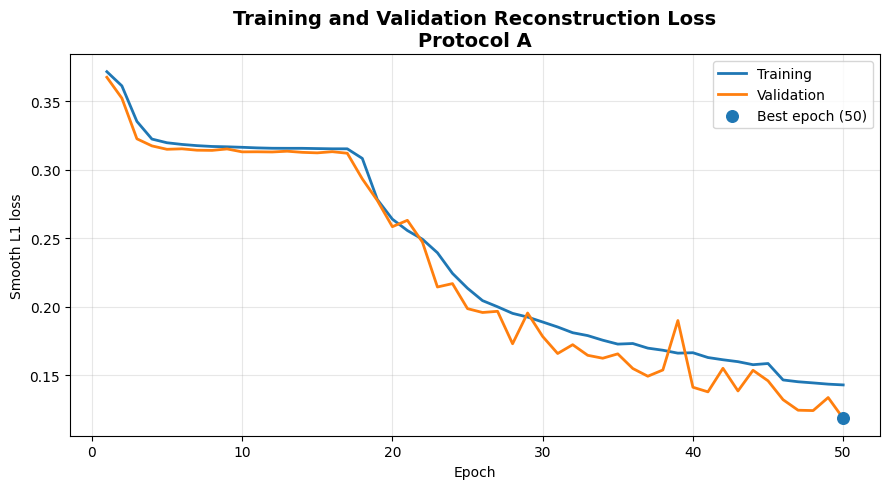

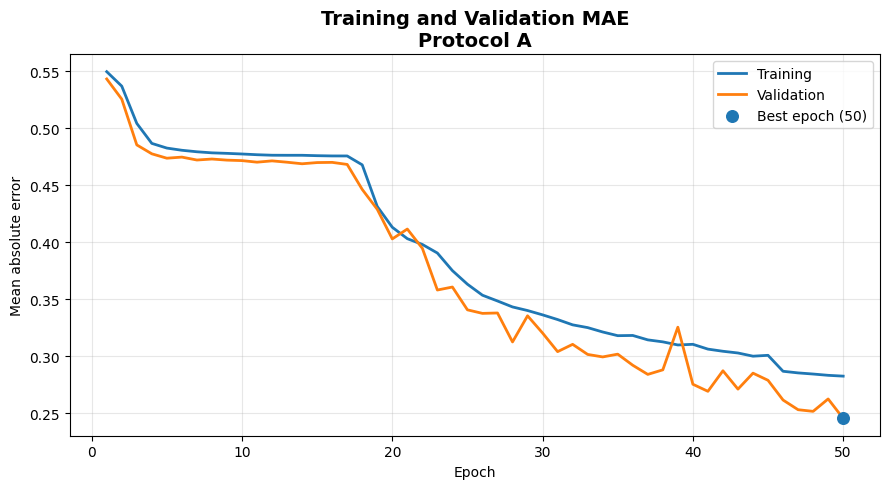

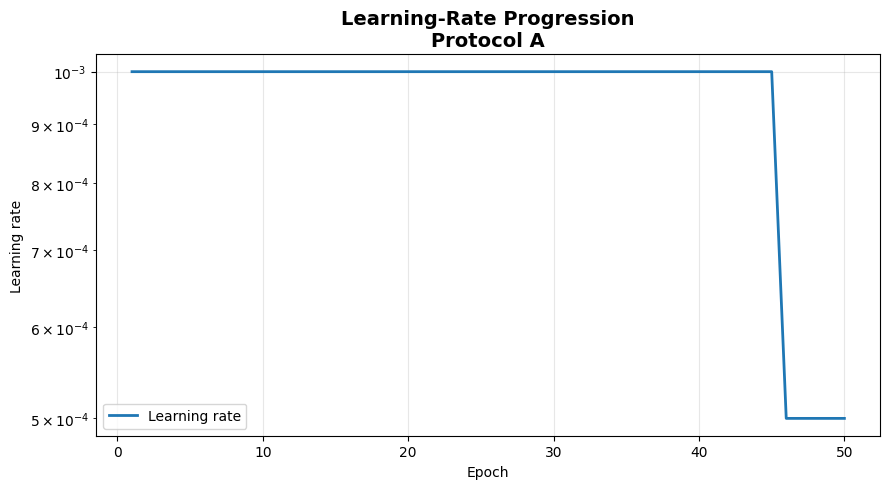

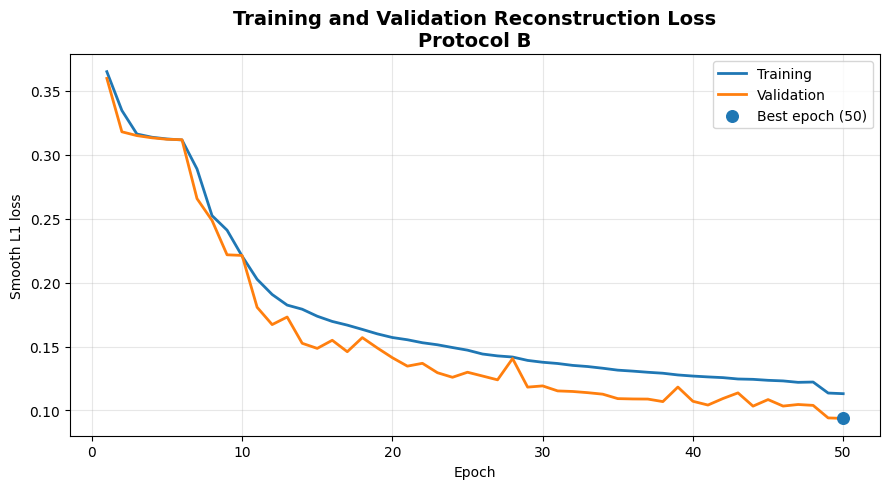

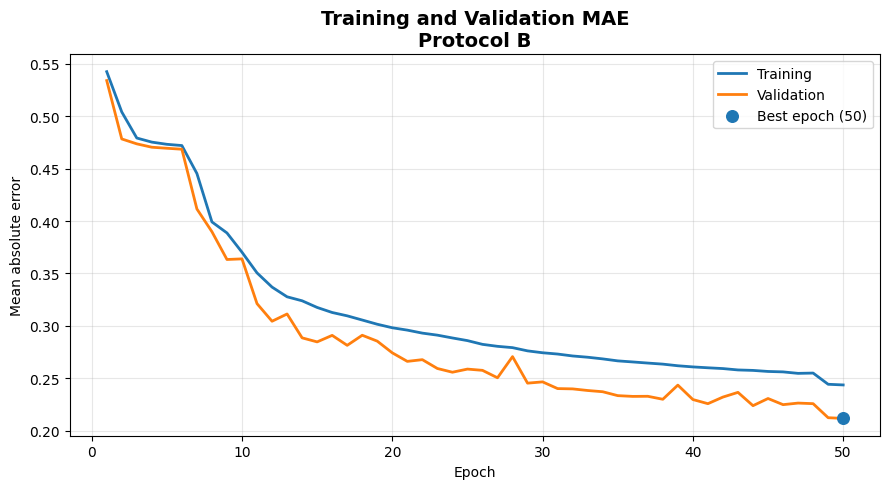

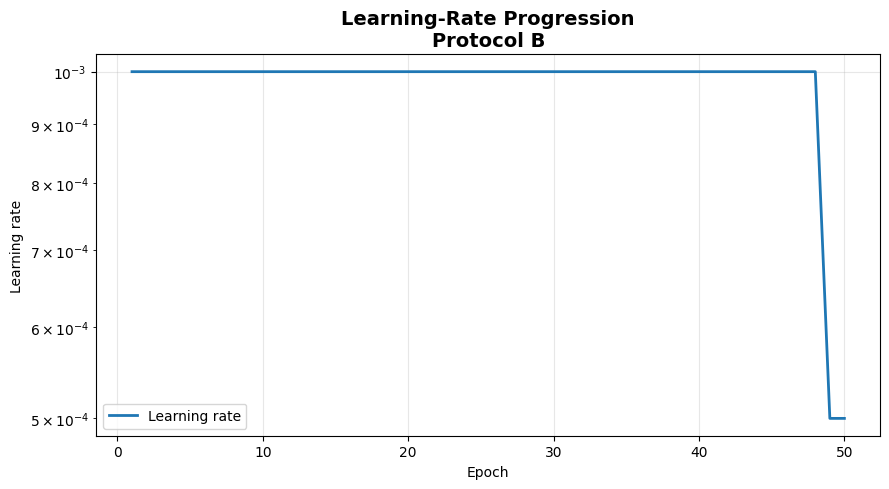

,Protocol,Epochs completed,Best epoch,Training loss at best,Best validation loss,Generalization gap,Best validation MAE,Final learning rate
0,A,50,50,0.142896,0.118472,-0.024423,0.245300,0.0005
1,B,50,50,0.113132,0.093811,-0.019321,0.211621,0.0005


Saved training figures:

Protocol A
  Loss          : /kaggle/working/outputs/protocol_A/figures/training/protocol_A_train_validation_loss.png
  Mae           : /kaggle/working/outputs/protocol_A/figures/training/protocol_A_train_validation_mae.png
  Learning Rate : /kaggle/working/outputs/protocol_A/figures/training/protocol_A_learning_rate.png

Protocol B
  Loss          : /kaggle/working/outputs/protocol_B/figures/training/protocol_B_train_validation_loss.png
  Mae           : /kaggle/working/outputs/protocol_B/figures/training/protocol_B_train_validation_mae.png
  Learning Rate : /kaggle/working/outputs/protocol_B/figures/training/protocol_B_learning_rate.png


In [13]:
# ==========================================================
# 11.3. Visualize Training History
# ==========================================================
# Plot the essential training diagnostics for each protocol:
# reconstruction loss, MAE, and learning-rate progression.

required_columns = {
    "epoch",
    "train_loss",
    "val_loss",
    "train_mae",
    "val_mae",
    "learning_rate",
}

training_summary_rows = []


def save_training_plot(
    history_df,
    protocol,
    train_column,
    validation_column,
    ylabel,
    title,
    filename,
    best_epoch=None,
):
    """Plot and save paired training and validation metrics."""
    figure_dir = (
        OUTPUT_ROOT
        / f"protocol_{protocol}"
        / "figures"
        / "training"
    )
    figure_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(
        history_df["epoch"],
        history_df[train_column],
        linewidth=2,
        label="Training",
    )

    ax.plot(
        history_df["epoch"],
        history_df[validation_column],
        linewidth=2,
        label="Validation",
    )

    if best_epoch is not None:
        best_row = history_df.loc[
            history_df["epoch"].eq(best_epoch)
        ]

        if not best_row.empty:
            ax.scatter(
                best_epoch,
                best_row.iloc[0][validation_column],
                s=70,
                zorder=5,
                label=f"Best epoch ({best_epoch})",
            )

    ax.set_title(
        f"{title}\nProtocol {protocol}",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend()

    fig.tight_layout()

    path = figure_dir / filename

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    return path


saved_training_figures = {}

for protocol in RUN_PROTOCOLS:
    data = protocol_data[protocol]

    if "history" not in data or "checkpoint" not in data:
        raise RuntimeError(
            f"Protocol {protocol} has not been trained."
        )

    history_df = data["history"].copy()
    missing_columns = required_columns - set(history_df.columns)

    if missing_columns:
        raise KeyError(
            f"Protocol {protocol} history is missing: "
            f"{sorted(missing_columns)}"
        )

    if history_df.empty:
        raise ValueError(
            f"Protocol {protocol} training history is empty."
        )

    numeric_history = history_df.select_dtypes(
        include=[np.number]
    )

    if not np.isfinite(numeric_history.to_numpy()).all():
        raise ValueError(
            f"Protocol {protocol} history contains NaN or Inf."
        )

    best_epoch = int(data["checkpoint"]["epoch"])
    best_validation_loss = float(
        data["checkpoint"]["validation_loss"]
    )

    best_row = history_df.loc[
        history_df["epoch"].eq(best_epoch)
    ]

    if best_row.empty:
        raise ValueError(
            f"Best epoch {best_epoch} is absent from "
            f"Protocol {protocol} history."
        )

    # Reconstruction loss
    loss_path = save_training_plot(
        history_df=history_df,
        protocol=protocol,
        train_column="train_loss",
        validation_column="val_loss",
        ylabel="Smooth L1 loss",
        title="Training and Validation Reconstruction Loss",
        filename=(
            f"protocol_{protocol}_"
            "train_validation_loss.png"
        ),
        best_epoch=best_epoch,
    )

    # Mean absolute reconstruction error
    mae_path = save_training_plot(
        history_df=history_df,
        protocol=protocol,
        train_column="train_mae",
        validation_column="val_mae",
        ylabel="Mean absolute error",
        title="Training and Validation MAE",
        filename=(
            f"protocol_{protocol}_"
            "train_validation_mae.png"
        ),
        best_epoch=best_epoch,
    )

    # Learning-rate progression
    figure_dir = (
        OUTPUT_ROOT
        / f"protocol_{protocol}"
        / "figures"
        / "training"
    )

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(
        history_df["epoch"],
        history_df["learning_rate"],
        linewidth=2,
        label="Learning rate",
    )

    ax.set_title(
        f"Learning-Rate Progression\nProtocol {protocol}",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning rate")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    ax.legend()

    fig.tight_layout()

    learning_rate_path = (
        figure_dir
        / f"protocol_{protocol}_learning_rate.png"
    )

    fig.savefig(
        learning_rate_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    saved_training_figures[protocol] = {
        "loss": loss_path,
        "mae": mae_path,
        "learning_rate": learning_rate_path,
    }

    training_loss_at_best = float(
        best_row.iloc[0]["train_loss"]
    )

    training_summary_rows.append({
        "Protocol": protocol,
        "Epochs completed": len(history_df),
        "Best epoch": best_epoch,
        "Training loss at best": training_loss_at_best,
        "Best validation loss": best_validation_loss,
        "Generalization gap": (
            best_validation_loss
            - training_loss_at_best
        ),
        "Best validation MAE": float(
            best_row.iloc[0]["val_mae"]
        ),
        "Final learning rate": float(
            history_df.iloc[-1]["learning_rate"]
        ),
    })


training_history_summary = pd.DataFrame(
    training_summary_rows
)

display(
    training_history_summary.round(6)
)

print("Saved training figures:")

for protocol, paths in saved_training_figures.items():
    print(f"\nProtocol {protocol}")
    for name, path in paths.items():
        print(f"  {name.replace('_', ' ').title():14s}: {path}")

# Pahse 6 - Model Evaluation

# 12.1 Load and Verify Best Checkpoints

In [14]:
# ==========================================================
# 12.1 Load and Verify Best Checkpoints
# ==========================================================
# Load one best model per protocol and verify checkpoint,
# preprocessing, and reconstruction compatibility.

evaluation_models = {}
verification_rows = []

for protocol in RUN_PROTOCOLS:
    data = protocol_data[protocol]
    checkpoint_path = (
        OUTPUT_ROOT
        / f"protocol_{protocol}"
        / f"lstm_autoencoder_protocol_{protocol}.pt"
    )

    if not checkpoint_path.is_file():
        raise FileNotFoundError(
            f"Protocol {protocol} checkpoint not found:\n{checkpoint_path}"
        )

    checkpoint = load_checkpoint(
        path=checkpoint_path,
        model=build_model(),
        device=DEVICE,
    )

    if checkpoint.get("protocol") != protocol:
        raise ValueError(
            f"Protocol mismatch in checkpoint: {checkpoint_path}"
        )

    # Verify saved window configuration.
    window_cfg = checkpoint["window_configuration"]

    expected_window_cfg = {
        "window_length": WINDOW_LENGTH,
        "window_stride": WINDOW_STRIDE,
        "number_of_leads": N_LEADS,
    }

    for key, expected in expected_window_cfg.items():
        if window_cfg.get(key) != expected:
            raise ValueError(
                f"Protocol {protocol}: invalid checkpoint value for {key}."
            )

    # Verify saved normalization statistics.
    normalization = checkpoint["normalization"]

    saved_mean = np.asarray(
        normalization["lead_mean"],
        dtype=np.float32,
    )
    saved_std = np.asarray(
        normalization["lead_std"],
        dtype=np.float32,
    )

    if saved_mean.shape != (N_LEADS,) or saved_std.shape != (N_LEADS,):
        raise ValueError(
            f"Protocol {protocol}: invalid normalization shape."
        )

    if not np.isfinite(saved_mean).all() or not np.isfinite(saved_std).all():
        raise ValueError(
            f"Protocol {protocol}: invalid normalization values."
        )

    if (saved_std <= 0).any():
        raise ValueError(
            f"Protocol {protocol}: normalization std must be positive."
        )

    if not np.allclose(
        saved_mean,
        data["normalization_mean"],
        rtol=1e-6,
        atol=1e-7,
    ):
        raise ValueError(
            f"Protocol {protocol}: normalization means do not match."
        )

    if not np.allclose(
        saved_std,
        data["normalization_std"],
        rtol=1e-6,
        atol=1e-7,
    ):
        raise ValueError(
            f"Protocol {protocol}: normalization stds do not match."
        )

    model = build_model()
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    # Verify one validation batch.
    batch = next(iter(data["valid_loader"]))
    ecg = batch["ecg"].to(
        DEVICE,
        dtype=torch.float32,
        non_blocking=True,
    )

    with torch.inference_mode():
        reconstruction = model(ecg)
        verification_loss = criterion(reconstruction, ecg)

    if reconstruction.shape != ecg.shape:
        raise RuntimeError(
            f"Protocol {protocol}: reconstruction shape mismatch."
        )

    if not torch.isfinite(reconstruction).all():
        raise RuntimeError(
            f"Protocol {protocol}: reconstruction contains NaN or Inf."
        )

    input_std = ecg.std().item()
    output_std = reconstruction.std().item()
    std_ratio = output_std / max(input_std, 1e-8)

    evaluation_models[protocol] = {
        "model": model,
        "checkpoint": checkpoint,
        "normalization_mean": saved_mean,
        "normalization_std": saved_std,
    }

    verification_rows.append({
        "Protocol": protocol,
        "Best epoch": int(checkpoint["epoch"]),
        "Saved validation loss": float(checkpoint["validation_loss"]),
        "Verification loss": float(verification_loss.item()),
        "Output/input std ratio": std_ratio,
        "Status": (
            "Passed"
            if std_ratio >= MIN_RECONSTRUCTION_STD_RATIO
            else "Low variance"
        ),
    })


checkpoint_verification = pd.DataFrame(verification_rows)
display(checkpoint_verification.round(6))

print(
    f"Verified {len(evaluation_models)} checkpoint(s) "
    "for reconstruction-error evaluation."
)

,Protocol,Best epoch,Saved validation loss,Verification loss,Output/input std ratio,Status
0,A,50,0.118472,0.120799,0.868814,Passed
1,B,50,0.093811,0.078327,0.889920,Passed


Verified 2 checkpoint(s) for reconstruction-error evaluation.


# 12.2 Compute Window-Level Reconstruction Errors

In [15]:
# ==========================================================
# 12.2 Compute Window-Level Reconstruction Errors
# ==========================================================
# Reconstruct every ECG window for both protocols and retain
# Smooth L1, MAE, MSE, and metadata for later aggregation.

def to_numpy(values):
    """Convert a batched tensor or sequence to a NumPy array."""
    if isinstance(values, torch.Tensor):
        return values.detach().cpu().numpy()

    return np.asarray(values)


def compute_window_errors(model, dataloader, device, description):
    """Return one reconstruction-error row per ECG window."""
    model.eval()

    frames = []
    statistics = {
        "input_sum": 0.0,
        "input_squared_sum": 0.0,
        "output_sum": 0.0,
        "output_squared_sum": 0.0,
        "count": 0,
    }

    with torch.inference_mode():
        for batch in tqdm(dataloader, desc=description, leave=False):
            ecg = batch["ecg"].to(
                device,
                dtype=torch.float32,
                non_blocking=True,
            )

            reconstruction = model(ecg)

            if reconstruction.shape != ecg.shape:
                raise RuntimeError(
                    f"{description}: reconstruction shape mismatch."
                )

            if not torch.isfinite(reconstruction).all():
                raise FloatingPointError(
                    f"{description}: reconstruction contains NaN or Inf."
                )

            error = reconstruction - ecg

            mae = error.abs().mean(dim=(1, 2))
            mse = error.square().mean(dim=(1, 2))
            smooth_l1 = torch.nn.functional.smooth_l1_loss(
                reconstruction,
                ecg,
                beta=SMOOTH_L1_BETA,
                reduction="none",
            ).mean(dim=(1, 2))

            scores = torch.stack(
                [smooth_l1, mae, mse],
                dim=1,
            )

            if not torch.isfinite(scores).all():
                raise FloatingPointError(
                    f"{description}: reconstruction scores contain NaN or Inf."
                )

            frames.append(
                pd.DataFrame({
                    "ecg_id": list(batch["ecg_id"]),
                    "segment_id": to_numpy(batch["segment_id"]),
                    "AF": to_numpy(batch["label"]).astype(np.int64),
                    "window_id": to_numpy(batch["window_id"]).astype(np.int64),
                    "start_sample": to_numpy(
                        batch["start_sample"]
                    ).astype(np.int64),
                    "end_sample": to_numpy(
                        batch["end_sample"]
                    ).astype(np.int64),
                    "smooth_l1": smooth_l1.cpu().numpy(),
                    "mae": mae.cpu().numpy(),
                    "mse": mse.cpu().numpy(),
                })
            )

            statistics["input_sum"] += ecg.sum().item()
            statistics["input_squared_sum"] += ecg.square().sum().item()
            statistics["output_sum"] += reconstruction.sum().item()
            statistics["output_squared_sum"] += (
                reconstruction.square().sum().item()
            )
            statistics["count"] += ecg.numel()

    if not frames:
        raise ValueError(f"{description}: no windows were evaluated.")

    results = pd.concat(frames, ignore_index=True)

    score_columns = ["smooth_l1", "mae", "mse"]

    if len(results) != len(dataloader.dataset):
        raise RuntimeError(
            f"{description}: score count does not match dataset size."
        )

    if results.duplicated(
        ["ecg_id", "segment_id", "window_id"]
    ).any():
        raise ValueError(
            f"{description}: duplicate window identifiers found."
        )

    if not results["AF"].isin([0, 1]).all():
        raise ValueError(f"{description}: invalid AF labels found.")

    if not np.isfinite(results[score_columns].to_numpy()).all():
        raise ValueError(f"{description}: invalid score values found.")

    if (results[score_columns] < 0).any().any():
        raise ValueError(f"{description}: negative errors found.")

    # Complete-split reconstruction-variance diagnostic
    count = statistics["count"]
    input_mean = statistics["input_sum"] / count
    output_mean = statistics["output_sum"] / count

    input_variance = max(
        statistics["input_squared_sum"] / count - input_mean**2,
        0.0,
    )
    output_variance = max(
        statistics["output_squared_sum"] / count - output_mean**2,
        0.0,
    )

    input_std = np.sqrt(input_variance)
    output_std = np.sqrt(output_variance)

    results.attrs.update({
        "input_std": float(input_std),
        "reconstruction_std": float(output_std),
        "reconstruction_std_ratio": float(
            output_std / max(input_std, 1e-8)
        ),
    })

    return results


window_errors = {}
summary_rows = []

for protocol in RUN_PROTOCOLS:
    data = protocol_data[protocol]
    model = evaluation_models[protocol]["model"]

    output_dir = (
        OUTPUT_ROOT
        / f"protocol_{protocol}"
        / "reconstruction_errors"
    )
    output_dir.mkdir(parents=True, exist_ok=True)

    window_errors[protocol] = {}

    for split, display_name in {
        "train": "Training",
        "valid": "Validation",
        "test": "Test",
    }.items():
        # Training loaders shuffle, so evaluation uses a dedicated
        # deterministic loader for every split.
        eval_loader = build_loader(
            data[f"{split}_dataset"],
            shuffle=False,
            seed=RANDOM_SEED,
        )

        errors = compute_window_errors(
            model=model,
            dataloader=eval_loader,
            device=DEVICE,
            description=f"Protocol {protocol} {display_name}",
        )

        window_errors[protocol][split] = errors
        data[f"{split}_window_errors"] = errors
        data[f"{split}_eval_loader"] = eval_loader

        file_split = "validation" if split == "valid" else split
        errors.to_csv(
            output_dir
            / f"protocol_{protocol}_{file_split}_window_errors.csv",
            index=False,
        )

        normal_mae = errors.loc[errors["AF"].eq(0), "mae"]
        af_mae = errors.loc[errors["AF"].eq(1), "mae"]

        summary_rows.append({
            "Protocol": protocol,
            "Split": display_name,
            "Recordings": errors["ecg_id"].nunique(),
            "Segments": errors[
                ["ecg_id", "segment_id"]
            ].drop_duplicates().shape[0],
            "Windows": len(errors),
            "Mean Smooth L1": errors["smooth_l1"].mean(),
            "Mean MAE": errors["mae"].mean(),
            "Mean MSE": errors["mse"].mean(),
            "Normal mean MAE": (
                normal_mae.mean() if not normal_mae.empty else np.nan
            ),
            "AF mean MAE": (
                af_mae.mean() if not af_mae.empty else np.nan
            ),
            "Output/input std ratio": (
                errors.attrs["reconstruction_std_ratio"]
            ),
        })


window_error_summary = pd.DataFrame(summary_rows)

display(
    window_error_summary.round({
        "Mean Smooth L1": 6,
        "Mean MAE": 6,
        "Mean MSE": 6,
        "Normal mean MAE": 6,
        "AF mean MAE": 6,
        "Output/input std ratio": 6,
    })
)

print(
    f"Computed and saved window-level reconstruction errors "
    f"for {len(RUN_PROTOCOLS)} protocol(s)."
)

Protocol A Training:   0%|          | 0/633 [00:00<?, ?it/s]

Protocol A Validation:   0%|          | 0/91 [00:00<?, ?it/s]

Protocol A Test:   0%|          | 0/90 [00:00<?, ?it/s]

Protocol B Training:   0%|          | 0/1385 [00:00<?, ?it/s]

Protocol B Validation:   0%|          | 0/91 [00:00<?, ?it/s]

Protocol B Test:   0%|          | 0/90 [00:00<?, ?it/s]

,Protocol,Split,Recordings,Segments,Windows,Mean Smooth L1,Mean MAE,Mean MSE,Normal mean MAE,AF mean MAE,Output/input std ratio
0,A,Training,1068,2129,40451,0.111316,0.236369,0.187235,0.230169,0.248734,0.852472
1,A,Validation,152,304,5776,0.118472,0.245300,0.205431,0.234050,0.256551,0.849922
2,A,Test,152,303,5757,0.111334,0.235490,0.191657,0.225727,0.245317,0.853524
3,B,Training,2340,4665,88635,0.081979,0.193797,0.125136,0.193797,NaN,0.880457
4,B,Validation,152,304,5776,0.093811,0.211621,0.147266,0.198458,0.224783,0.873339
5,B,Test,152,303,5757,0.087675,0.202094,0.137002,0.189299,0.214973,0.878304


Computed and saved window-level reconstruction errors for 2 protocol(s).


# 12.3 Select and Apply Recording-Level Score Aggregation

In [16]:
# ==========================================================
# 12.3 Select and Apply Recording-Level Score Aggregation
# ==========================================================
# Convert window errors into segment and recording scores.
# Select each protocol's aggregation using validation data only.

import json

SCORE_COLUMNS = ("smooth_l1", "mae", "mse")
WINDOW_AGGREGATIONS = ("mean", "median", "p90", "max")
RECORDING_AGGREGATIONS = ("mean", "median", "max")


def aggregate_array(values, method):
    """Aggregate a non-empty collection of finite scores."""
    values = np.asarray(values, dtype=np.float64)

    if values.size == 0 or not np.isfinite(values).all():
        raise ValueError("Cannot aggregate empty or invalid scores.")

    functions = {
        "mean": np.mean,
        "median": np.median,
        "p90": lambda x: np.quantile(x, 0.90),
        "max": np.max,
    }

    if method not in functions:
        raise ValueError(f"Unsupported aggregation method: {method}")

    return float(functions[method](values))


def build_recording_scores(
    window_df,
    score_name,
    window_to_segment,
    segment_to_recording,
):
    """Aggregate window scores into segment and recording scores."""
    required = {
        "ecg_id",
        "segment_id",
        "AF",
        "window_id",
        score_name,
    }

    missing = required - set(window_df.columns)

    if missing:
        raise KeyError(f"Window scores are missing: {sorted(missing)}")

    if (window_df.groupby("ecg_id")["AF"].nunique() > 1).any():
        raise ValueError("Inconsistent AF labels found within a recording.")

    segment_scores = (
        window_df
        .groupby(["ecg_id", "segment_id", "AF"], as_index=False)
        .agg(
            segment_score=(
                score_name,
                lambda x: aggregate_array(x, window_to_segment),
            ),
            number_of_windows=("window_id", "count"),
        )
    )

    recording_scores = (
        segment_scores
        .groupby(["ecg_id", "AF"], as_index=False)
        .agg(
            recording_score=(
                "segment_score",
                lambda x: aggregate_array(x, segment_to_recording),
            ),
            number_of_segments=("segment_id", "nunique"),
            number_of_windows=("number_of_windows", "sum"),
        )
    )

    if not recording_scores["ecg_id"].is_unique:
        raise RuntimeError("Aggregation did not produce one row per recording.")

    if not np.isfinite(
        recording_scores["recording_score"]
    ).all():
        raise ValueError("Recording scores contain NaN or Inf.")

    return segment_scores, recording_scores


aggregation_results = {}
candidate_rows = []
selected_rows = []
score_summary_rows = []

for protocol in RUN_PROTOCOLS:
    data = protocol_data[protocol]
    validation_errors = window_errors[protocol]["valid"]

    protocol_candidates = []

    # Compare candidate configurations using validation labels only.
    for score_name in SCORE_COLUMNS:
        for window_method in WINDOW_AGGREGATIONS:
            for recording_method in RECORDING_AGGREGATIONS:
                _, recording_df = build_recording_scores(
                    window_df=validation_errors,
                    score_name=score_name,
                    window_to_segment=window_method,
                    segment_to_recording=recording_method,
                )

                labels = recording_df["AF"].to_numpy()
                scores = recording_df["recording_score"].to_numpy()

                if set(np.unique(labels)) != {0, 1}:
                    raise ValueError(
                        f"Protocol {protocol} validation must contain both classes."
                    )

                row = {
                    "Protocol": protocol,
                    "Score": score_name,
                    "Window → segment": window_method,
                    "Segment → recording": recording_method,
                    "Validation ROC-AUC": roc_auc_score(labels, scores),
                    "Validation PR-AUC": average_precision_score(
                        labels, scores
                    ),
                    "Recordings": len(recording_df),
                }

                protocol_candidates.append(row)
                candidate_rows.append(row)

    candidate_df = (
        pd.DataFrame(protocol_candidates)
        .sort_values(
            ["Validation ROC-AUC", "Validation PR-AUC"],
            ascending=False,
        )
        .reset_index(drop=True)
    )

    best = candidate_df.iloc[0]

    selected_score = best["Score"]
    selected_window_method = best["Window → segment"]
    selected_recording_method = best["Segment → recording"]

    selected_rows.append(best.to_dict())

    protocol_output = (
        OUTPUT_ROOT
        / f"protocol_{protocol}"
        / "aggregated_scores"
    )
    protocol_output.mkdir(parents=True, exist_ok=True)

    aggregation_results[protocol] = {
        "configuration": {
            "score_name": selected_score,
            "window_to_segment": selected_window_method,
            "segment_to_recording": selected_recording_method,
            "validation_roc_auc": float(best["Validation ROC-AUC"]),
            "validation_pr_auc": float(best["Validation PR-AUC"]),
        },
        "candidates": candidate_df,
    }

    # Apply the selected validation configuration to every split.
    for split, display_name in {
        "train": "Training",
        "valid": "Validation",
        "test": "Test",
    }.items():
        segment_df, recording_df = build_recording_scores(
            window_df=window_errors[protocol][split],
            score_name=selected_score,
            window_to_segment=selected_window_method,
            segment_to_recording=selected_recording_method,
        )

        aggregation_results[protocol][f"{split}_segment_scores"] = segment_df
        aggregation_results[protocol][f"{split}_recording_scores"] = recording_df

        data[f"{split}_segment_scores"] = segment_df
        data[f"{split}_recording_scores"] = recording_df

        expected_recordings = len(data[f"{split}_labels"])

        if len(recording_df) != expected_recordings:
            raise RuntimeError(
                f"Protocol {protocol} {display_name}: "
                "recording count changed after aggregation."
            )

        segment_df.to_csv(
            protocol_output
            / f"protocol_{protocol}_{split}_segment_scores.csv",
            index=False,
        )

        recording_df.to_csv(
            protocol_output
            / f"protocol_{protocol}_{split}_recording_scores.csv",
            index=False,
        )

        normal_scores = recording_df.loc[
            recording_df["AF"].eq(0),
            "recording_score",
        ]
        af_scores = recording_df.loc[
            recording_df["AF"].eq(1),
            "recording_score",
        ]

        score_summary_rows.append({
            "Protocol": protocol,
            "Split": display_name,
            "Recordings": len(recording_df),
            "Mean score": recording_df["recording_score"].mean(),
            "Median score": recording_df["recording_score"].median(),
            "Normal mean": (
                normal_scores.mean()
                if not normal_scores.empty
                else np.nan
            ),
            "AF mean": (
                af_scores.mean()
                if not af_scores.empty
                else np.nan
            ),
        })

    # Verify split isolation after aggregation.
    train_ids = set(data["train_recording_scores"]["ecg_id"])
    valid_ids = set(data["valid_recording_scores"]["ecg_id"])
    test_ids = set(data["test_recording_scores"]["ecg_id"])

    if (
        train_ids & valid_ids
        or train_ids & test_ids
        or valid_ids & test_ids
    ):
        raise RuntimeError(
            f"Protocol {protocol}: recording leakage detected."
        )

    candidate_df.to_csv(
        protocol_output
        / f"protocol_{protocol}_aggregation_candidates.csv",
        index=False,
    )

    with open(
        protocol_output
        / f"protocol_{protocol}_selected_aggregation.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            aggregation_results[protocol]["configuration"],
            file,
            indent=2,
        )


selected_aggregation_summary = pd.DataFrame(selected_rows)
recording_score_summary = pd.DataFrame(score_summary_rows)

print("Selected recording-score configurations")
display(
    selected_aggregation_summary[
        [
            "Protocol",
            "Score",
            "Window → segment",
            "Segment → recording",
            "Validation ROC-AUC",
            "Validation PR-AUC",
        ]
    ].round(6)
)

print("Top five validation configurations per protocol")
display(
    pd.concat(
        [
            aggregation_results[protocol]["candidates"].head(5)
            for protocol in RUN_PROTOCOLS
        ],
        ignore_index=True,
    ).round(6)
)

print("Recording-level score summary")
display(recording_score_summary.round(6))

print(
    "Aggregation selected using validation data only; "
    "test labels were not used for configuration selection."
)

Selected recording-score configurations


,Protocol,Score,Window → segment,Segment → recording,Validation ROC-AUC,Validation PR-AUC
0,A,mae,median,max,0.656856,0.639873
1,B,mae,median,max,0.682652,0.669064


Top five validation configurations per protocol


,Protocol,Score,Window → segment,Segment → recording,Validation ROC-AUC,Validation PR-AUC,Recordings
0,A,mae,median,max,0.656856,0.639873,152
1,A,mae,median,mean,0.649411,0.633161,152
2,A,mae,median,median,0.649411,0.633161,152
3,A,smooth_l1,median,max,0.645602,0.639147,152
4,A,mae,mean,max,0.642313,0.639168,152
5,B,mae,median,max,0.682652,0.669064,152
6,B,mae,median,mean,0.679709,0.650703,152
7,B,mae,median,median,0.679709,0.650703,152
8,B,mae,mean,max,0.669321,0.663180,152
9,B,mae,p90,max,0.668283,0.650000,152


Recording-level score summary


,Protocol,Split,Recordings,Mean score,Median score,Normal mean,AF mean
0,A,Training,1068,0.250149,0.243118,0.241650,0.267147
1,A,Validation,152,0.262286,0.250285,0.247877,0.276696
2,A,Test,152,0.250563,0.245739,0.239780,0.261345
3,B,Training,2340,0.202042,0.194775,0.202042,NaN
4,B,Validation,152,0.224344,0.217730,0.208243,0.240444
5,B,Test,152,0.213773,0.206661,0.199747,0.227800


Aggregation selected using validation data only; test labels were not used for configuration selection.


# 12.4 Select Validation-Derived Anomaly Thresholds

In [17]:
# ==========================================================
# 12.4 Select Validation-Derived Anomaly Thresholds
# ==========================================================
# Treat the anomaly threshold as a hyperparameter:
# select it on validation recordings and keep the test set
# untouched until final evaluation.

THRESHOLD_PERCENTILE = 95
PRIMARY_THRESHOLD_METHOD = "normal_validation_percentile"

if not 0 < THRESHOLD_PERCENTILE < 100:
    raise ValueError("THRESHOLD_PERCENTILE must be between 0 and 100.")


def evaluate_threshold(labels, scores, threshold):
    """Calculate validation metrics for one fixed threshold."""
    predictions = (scores >= threshold).astype(np.int64)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()

    specificity = tn / max(tn + fp, 1)

    return {
        "threshold": float(threshold),
        "precision": precision_score(
            labels, predictions, zero_division=0
        ),
        "recall": recall_score(
            labels, predictions, zero_division=0
        ),
        "specificity": specificity,
        "f1_score": f1_score(
            labels, predictions, zero_division=0
        ),
        "balanced_accuracy": balanced_accuracy_score(
            labels, predictions
        ),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "predictions": predictions,
    }


def find_f1_threshold(labels, scores):
    """Return the validation threshold that maximizes F1."""
    precision, recall, thresholds = precision_recall_curve(
        labels,
        scores,
    )

    if len(thresholds) == 0:
        raise ValueError("No candidate F1 thresholds were generated.")

    f1_values = (
        2 * precision[:-1] * recall[:-1]
        / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    )

    return float(thresholds[int(np.nanargmax(f1_values))])


threshold_results = {}
threshold_summary_rows = []

for protocol in RUN_PROTOCOLS:
    data = protocol_data[protocol]
    validation_scores = data["valid_recording_scores"].copy()

    labels = validation_scores["AF"].to_numpy(dtype=np.int64)
    scores = validation_scores[
        "recording_score"
    ].to_numpy(dtype=np.float64)

    if set(np.unique(labels)) != {0, 1}:
        raise ValueError(
            f"Protocol {protocol}: validation requires Normal and AF."
        )

    if not np.isfinite(scores).all() or (scores < 0).any():
        raise ValueError(
            f"Protocol {protocol}: invalid validation scores."
        )

    # Primary unsupervised threshold: Normal validation only.
    normal_scores = scores[labels == 0]

    if len(normal_scores) == 0:
        raise ValueError(
            f"Protocol {protocol}: no Normal validation scores."
        )

    primary_threshold = float(
        np.quantile(
            normal_scores,
            THRESHOLD_PERCENTILE / 100,
        )
    )

    # Label-informed threshold retained only for comparison.
    f1_threshold = find_f1_threshold(labels, scores)

    primary_metrics = evaluate_threshold(
        labels,
        scores,
        primary_threshold,
    )
    f1_metrics = evaluate_threshold(
        labels,
        scores,
        f1_threshold,
    )

    validation_scores["prediction_primary"] = (
        primary_metrics["predictions"]
    )
    validation_scores["prediction_f1"] = (
        f1_metrics["predictions"]
    )

    configuration = aggregation_results[protocol]["configuration"]

    threshold_results[protocol] = {
        "primary_method": PRIMARY_THRESHOLD_METHOD,
        "percentile": THRESHOLD_PERCENTILE,
        "primary_threshold": primary_threshold,
        "f1_threshold": f1_threshold,
        "primary_metrics": {
            key: value
            for key, value in primary_metrics.items()
            if key != "predictions"
        },
        "f1_metrics": {
            key: value
            for key, value in f1_metrics.items()
            if key != "predictions"
        },
    }

    data["thresholds"] = threshold_results[protocol]
    data["valid_recording_scores"] = validation_scores

    for method, metrics in {
        "Primary unsupervised": primary_metrics,
        "Validation F1 optimized": f1_metrics,
    }.items():
        threshold_summary_rows.append({
            "Protocol": protocol,
            "Method": method,
            "Threshold": metrics["threshold"],
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "Specificity": metrics["specificity"],
            "F1-score": metrics["f1_score"],
            "Balanced accuracy": metrics["balanced_accuracy"],
            "TN": metrics["true_negatives"],
            "FP": metrics["false_positives"],
            "FN": metrics["false_negatives"],
            "TP": metrics["true_positives"],
        })

    # Save protocol-specific threshold outputs.
    output_dir = (
        OUTPUT_ROOT
        / f"protocol_{protocol}"
        / "thresholds"
    )
    output_dir.mkdir(parents=True, exist_ok=True)

    validation_scores.to_csv(
        output_dir
        / f"protocol_{protocol}_validation_predictions.csv",
        index=False,
    )

    with open(
        output_dir
        / f"protocol_{protocol}_selected_thresholds.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            {
                "protocol": protocol,
                "score_name": configuration["score_name"],
                "window_to_segment": (
                    configuration["window_to_segment"]
                ),
                "segment_to_recording": (
                    configuration["segment_to_recording"]
                ),
                **threshold_results[protocol],
            },
            file,
            indent=2,
        )


threshold_summary = pd.DataFrame(threshold_summary_rows)

display(
    threshold_summary.round({
        "Threshold": 6,
        "Precision": 4,
        "Recall": 4,
        "Specificity": 4,
        "F1-score": 4,
        "Balanced accuracy": 4,
    })
)

print(
    "Thresholds selected from validation recording scores only; "
    "test data remain untouched."
)

,Protocol,Method,Threshold,Precision,Recall,Specificity,F1-score,Balanced accuracy,TN,FP,FN,TP
0,A,Primary unsupervised,0.339208,0.7143,0.1316,0.9474,0.2222,0.5395,72,4,66,10
1,A,Validation F1 optimized,0.181348,0.5137,0.9868,0.0658,0.6757,0.5263,5,71,1,75
2,B,Primary unsupervised,0.307567,0.6364,0.0921,0.9474,0.1609,0.5197,72,4,69,7
3,B,Validation F1 optimized,0.173709,0.5496,0.9474,0.2237,0.6957,0.5855,17,59,4,72


Thresholds selected from validation recording scores only; test data remain untouched.


# 12.5 Generate Recording-Level Anomaly Predictions

In [18]:
# ==========================================================
# 12.5 Generate Recording-Level Anomaly Predictions
# ==========================================================
# Apply each protocol's fixed validation-derived thresholds
# to train, validation, and test recording scores.

def predict_recordings(recording_scores, primary_threshold, f1_threshold):
    """Apply fixed thresholds to one row per ECG recording."""
    required = {"ecg_id", "AF", "recording_score"}
    missing = required - set(recording_scores.columns)

    if missing:
        raise KeyError(
            f"Recording scores are missing columns: {sorted(missing)}"
        )

    if not np.isfinite([primary_threshold, f1_threshold]).all():
        raise ValueError("Thresholds must be finite.")

    predictions = recording_scores.copy().reset_index(drop=True)

    if not predictions["ecg_id"].is_unique:
        raise ValueError("Expected exactly one score per ECG recording.")

    predictions["prediction_primary"] = (
        predictions["recording_score"] >= primary_threshold
    ).astype(np.int64)

    predictions["prediction_f1"] = (
        predictions["recording_score"] >= f1_threshold
    ).astype(np.int64)

    predictions["predicted_class_primary"] = (
        predictions["prediction_primary"]
        .map({0: "Normal", 1: "Anomalous"})
    )

    predictions["score_minus_primary_threshold"] = (
        predictions["recording_score"] - primary_threshold
    )

    predictions["primary_threshold"] = primary_threshold
    predictions["f1_threshold"] = f1_threshold

    return predictions


prediction_results = {}
prediction_summary_rows = []

for protocol in RUN_PROTOCOLS:
    data = protocol_data[protocol]
    thresholds = threshold_results[protocol]
    aggregation = aggregation_results[protocol]["configuration"]

    primary_threshold = thresholds["primary_threshold"]
    f1_threshold = thresholds["f1_threshold"]

    output_dir = (
        OUTPUT_ROOT
        / f"protocol_{protocol}"
        / "predictions"
    )
    output_dir.mkdir(parents=True, exist_ok=True)

    prediction_results[protocol] = {}

    for split, display_name in {
        "train": "Training",
        "valid": "Validation",
        "test": "Test",
    }.items():
        predictions = predict_recordings(
            recording_scores=data[f"{split}_recording_scores"],
            primary_threshold=primary_threshold,
            f1_threshold=f1_threshold,
        )

        predictions["protocol"] = protocol
        predictions["score_name"] = aggregation["score_name"]
        predictions["window_to_segment"] = (
            aggregation["window_to_segment"]
        )
        predictions["segment_to_recording"] = (
            aggregation["segment_to_recording"]
        )
        predictions["primary_threshold_method"] = (
            thresholds["primary_method"]
        )

        prediction_results[protocol][split] = predictions
        data[f"{split}_predictions"] = predictions

        file_split = "validation" if split == "valid" else split

        predictions.to_csv(
            output_dir
            / f"protocol_{protocol}_{file_split}_recording_predictions.csv",
            index=False,
        )

        for method, column in {
            "Primary unsupervised": "prediction_primary",
            "Validation F1 optimized": "prediction_f1",
        }.items():
            anomalous_count = int(predictions[column].sum())
            total = len(predictions)

            prediction_summary_rows.append({
                "Protocol": protocol,
                "Split": display_name,
                "Threshold method": method,
                "Recordings": total,
                "Predicted normal": total - anomalous_count,
                "Predicted anomalous": anomalous_count,
                "Predicted anomaly rate (%)": (
                    100 * anomalous_count / max(total, 1)
                ),
                "Actual Normal": int(predictions["AF"].eq(0).sum()),
                "Actual AF": int(predictions["AF"].eq(1).sum()),
            })

    # Confirm recording-level split isolation.
    train_ids = set(data["train_predictions"]["ecg_id"])
    valid_ids = set(data["valid_predictions"]["ecg_id"])
    test_ids = set(data["test_predictions"]["ecg_id"])

    if train_ids & valid_ids or train_ids & test_ids or valid_ids & test_ids:
        raise RuntimeError(
            f"Protocol {protocol}: prediction split leakage detected."
        )


prediction_summary = pd.DataFrame(prediction_summary_rows)

display(
    prediction_summary.round({
        "Predicted anomaly rate (%)": 2,
    })
)

print(
    "Recording-level predictions generated with fixed "
    "validation-derived thresholds for both protocols."
)

,Protocol,Split,Threshold method,Recordings,Predicted normal,Predicted anomalous,Predicted anomaly rate (%),Actual Normal,Actual AF
0,A,Training,Primary unsupervised,1068,989,79,7.40,712,356
1,A,Training,Validation F1 optimized,1068,101,967,90.54,712,356
2,A,Validation,Primary unsupervised,152,138,14,9.21,76,76
3,A,Validation,Validation F1 optimized,152,6,146,96.05,76,76
4,A,Test,Primary unsupervised,152,144,8,5.26,76,76
5,A,Test,Validation F1 optimized,152,9,143,94.08,76,76
6,B,Training,Primary unsupervised,2340,2255,85,3.63,2340,0
7,B,Training,Validation F1 optimized,2340,710,1630,69.66,2340,0
8,B,Validation,Primary unsupervised,152,141,11,7.24,76,76
9,B,Validation,Validation F1 optimized,152,21,131,86.18,76,76


Recording-level predictions generated with fixed validation-derived thresholds for both protocols.


# 12.6 Final Recording-Level Test Evaluation

,Protocol,Threshold method,Threshold,Accuracy,Balanced accuracy,Precision,Recall / sensitivity,Specificity,F1-score,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,A,Primary unsupervised,0.339208,0.5000,0.5000,0.5000,0.0526,0.9474,0.0952,0.6413,0.5751,72,4,72,4
1,A,Validation F1 optimized,0.181348,0.5329,0.5329,0.5175,0.9737,0.0921,0.6758,0.6413,0.5751,7,69,2,74
2,B,Primary unsupervised,0.307567,0.5066,0.5066,0.5714,0.0526,0.9605,0.0964,0.6851,0.6138,73,3,72,4
3,B,Validation F1 optimized,0.173709,0.6513,0.6513,0.6000,0.9079,0.3947,0.7225,0.6851,0.6138,30,46,7,69


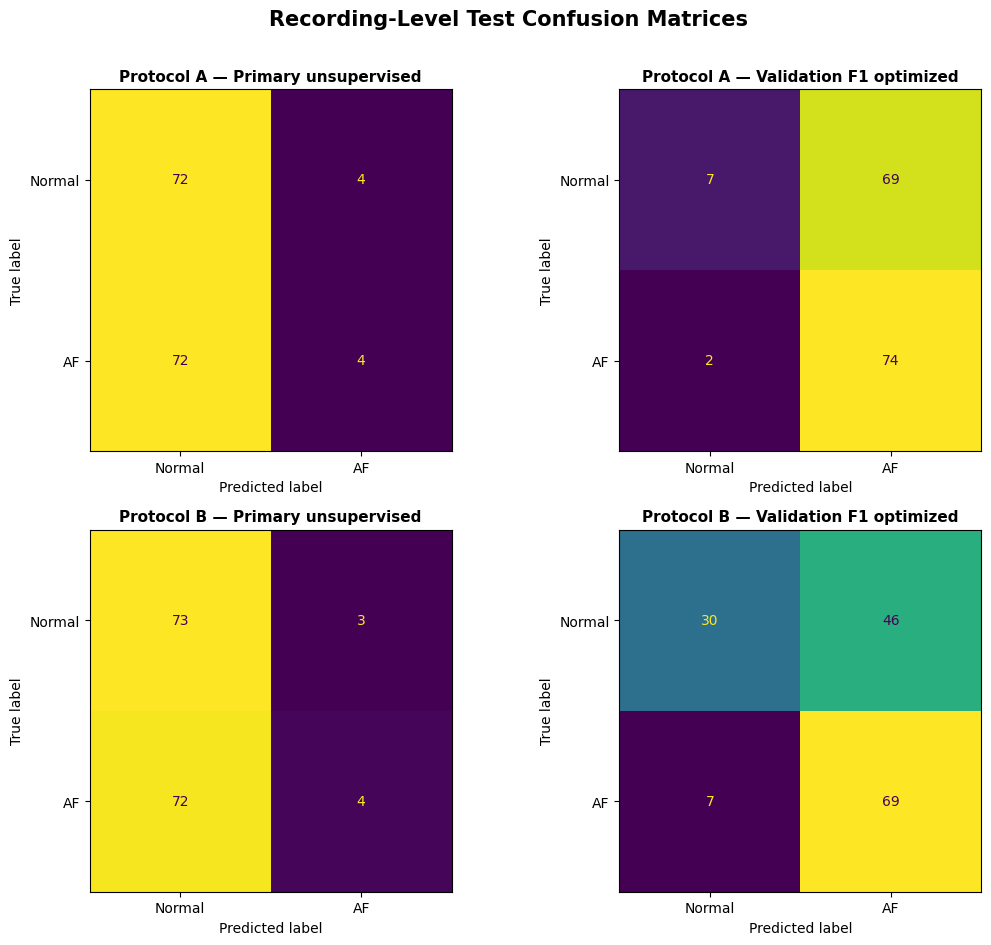

Final test evaluation completed for both protocols. Combined confusion matrices saved to: /kaggle/working/outputs/comparison_figures/protocol_A_B_test_confusion_matrices.png


In [19]:
# ==========================================================
# 12.6 Final Recording-Level Test Evaluation
# ==========================================================
# Evaluate both protocols once on the untouched test set.
# Report continuous-score performance and both fixed
# validation-derived threshold strategies.

def calculate_test_metrics(labels, predictions, threshold, method):
    """Calculate binary recording-level classification metrics."""
    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()

    specificity = tn / max(tn + fp, 1)
    npv = tn / max(tn + fn, 1)

    return {
        "Threshold method": method,
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(labels, predictions),
        "Balanced accuracy": balanced_accuracy_score(
            labels, predictions
        ),
        "Precision": precision_score(
            labels, predictions, zero_division=0
        ),
        "Recall / sensitivity": recall_score(
            labels, predictions, zero_division=0
        ),
        "Specificity": specificity,
        "Negative predictive value": npv,
        "F1-score": f1_score(
            labels, predictions, zero_division=0
        ),
        "False positive rate": fp / max(fp + tn, 1),
        "False negative rate": fn / max(fn + tp, 1),
        "Predicted anomaly rate": float(np.mean(predictions)),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "confusion_matrix": np.array([[tn, fp], [fn, tp]]),
    }


evaluation_results = {}
evaluation_rows = []
confusion_matrices = {}

for protocol in RUN_PROTOCOLS:
    data = protocol_data[protocol]
    predictions = data["test_predictions"].copy()
    thresholds = threshold_results[protocol]

    labels = predictions["AF"].to_numpy(dtype=np.int64)
    scores = predictions["recording_score"].to_numpy(dtype=np.float64)
    primary_predictions = predictions[
        "prediction_primary"
    ].to_numpy(dtype=np.int64)
    f1_predictions = predictions[
        "prediction_f1"
    ].to_numpy(dtype=np.int64)

    if not predictions["ecg_id"].is_unique:
        raise ValueError(
            f"Protocol {protocol}: expected one row per test recording."
        )

    if set(np.unique(labels)) != {0, 1}:
        raise ValueError(
            f"Protocol {protocol}: test set must contain Normal and AF."
        )

    if not np.isfinite(scores).all():
        raise ValueError(
            f"Protocol {protocol}: test scores contain NaN or Inf."
        )

    # Threshold-independent ranking metrics
    roc_auc = roc_auc_score(labels, scores)
    pr_auc = average_precision_score(labels, scores)

    strategy_inputs = {
        "Primary unsupervised": (
            primary_predictions,
            thresholds["primary_threshold"],
        ),
        "Validation F1 optimized": (
            f1_predictions,
            thresholds["f1_threshold"],
        ),
    }

    protocol_metrics = {}

    for method, (predicted, threshold) in strategy_inputs.items():
        metrics = calculate_test_metrics(
            labels=labels,
            predictions=predicted,
            threshold=threshold,
            method=method,
        )

        metrics["ROC-AUC"] = roc_auc
        metrics["PR-AUC"] = pr_auc
        protocol_metrics[method] = metrics
        confusion_matrices[(protocol, method)] = (
            metrics["confusion_matrix"]
        )

        evaluation_rows.append({
            "Protocol": protocol,
            **{
                key: value
                for key, value in metrics.items()
                if key != "confusion_matrix"
            },
        })

    # Add outcomes for later qualitative analysis.
    predictions["correct_primary"] = (
        predictions["AF"]
        == predictions["prediction_primary"]
    )

    predictions["primary_outcome"] = np.select(
        [
            predictions["AF"].eq(0)
            & predictions["prediction_primary"].eq(0),

            predictions["AF"].eq(0)
            & predictions["prediction_primary"].eq(1),

            predictions["AF"].eq(1)
            & predictions["prediction_primary"].eq(0),

            predictions["AF"].eq(1)
            & predictions["prediction_primary"].eq(1),
        ],
        [
            "True Negative",
            "False Positive",
            "False Negative",
            "True Positive",
        ],
        default="Unknown",
    )

    data["test_predictions"] = predictions
    data["test_evaluation"] = protocol_metrics

    evaluation_results[protocol] = {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "primary": protocol_metrics["Primary unsupervised"],
        "f1_optimized": protocol_metrics[
            "Validation F1 optimized"
        ],
    }

    # Save protocol-specific evaluation outputs.
    output_dir = (
        OUTPUT_ROOT
        / f"protocol_{protocol}"
        / "evaluation"
    )
    output_dir.mkdir(parents=True, exist_ok=True)

    predictions.to_csv(
        output_dir
        / f"protocol_{protocol}_test_predictions_evaluated.csv",
        index=False,
    )

    protocol_table = pd.DataFrame(
        [
            {
                key: value
                for key, value in metrics.items()
                if key != "confusion_matrix"
            }
            for metrics in protocol_metrics.values()
        ]
    )

    protocol_table.to_csv(
        output_dir
        / f"protocol_{protocol}_test_metrics.csv",
        index=False,
    )

    with open(
        output_dir
        / f"protocol_{protocol}_test_evaluation.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            {
                "protocol": protocol,
                "evaluation_level": "ECG recording",
                "test_recordings": int(len(predictions)),
                "normal_recordings": int((labels == 0).sum()),
                "af_recordings": int((labels == 1).sum()),
                "roc_auc": float(roc_auc),
                "pr_auc": float(pr_auc),
                "primary": {
                    key: (
                        value.tolist()
                        if isinstance(value, np.ndarray)
                        else value
                    )
                    for key, value in protocol_metrics[
                        "Primary unsupervised"
                    ].items()
                },
                "f1_optimized": {
                    key: (
                        value.tolist()
                        if isinstance(value, np.ndarray)
                        else value
                    )
                    for key, value in protocol_metrics[
                        "Validation F1 optimized"
                    ].items()
                },
            },
            file,
            indent=2,
        )


# ----------------------------------------------------------
# Combined evaluation table
# ----------------------------------------------------------
test_evaluation_summary = pd.DataFrame(evaluation_rows)

metric_columns = [
    "Protocol",
    "Threshold method",
    "Threshold",
    "Accuracy",
    "Balanced accuracy",
    "Precision",
    "Recall / sensitivity",
    "Specificity",
    "F1-score",
    "ROC-AUC",
    "PR-AUC",
    "TN",
    "FP",
    "FN",
    "TP",
]

display(
    test_evaluation_summary[metric_columns].round({
        "Threshold": 6,
        "Accuracy": 4,
        "Balanced accuracy": 4,
        "Precision": 4,
        "Recall / sensitivity": 4,
        "Specificity": 4,
        "F1-score": 4,
        "ROC-AUC": 4,
        "PR-AUC": 4,
    })
)


# ----------------------------------------------------------
# Combined confusion-matrix figure
# ----------------------------------------------------------
figure_dir = OUTPUT_ROOT / "comparison_figures"
figure_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(
    nrows=len(RUN_PROTOCOLS),
    ncols=2,
    figsize=(11, 4.8 * len(RUN_PROTOCOLS)),
)

axes = np.atleast_2d(axes)

methods = [
    "Primary unsupervised",
    "Validation F1 optimized",
]

for row, protocol in enumerate(RUN_PROTOCOLS):
    for column, method in enumerate(methods):
        ax = axes[row, column]

        ConfusionMatrixDisplay(
            confusion_matrix=confusion_matrices[(protocol, method)],
            display_labels=["Normal", "AF"],
        ).plot(
            ax=ax,
            colorbar=False,
            values_format="d",
        )

        ax.set_title(
            f"Protocol {protocol} — {method}",
            fontsize=11,
            fontweight="bold",
        )

fig.suptitle(
    "Recording-Level Test Confusion Matrices",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

confusion_figure_path = (
    figure_dir
    / "protocol_A_B_test_confusion_matrices.png"
)

fig.savefig(
    confusion_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    "Final test evaluation completed for both protocols. "
    f"Combined confusion matrices saved to: {confusion_figure_path}"
)

# 12.7 Compare Test ROC and Precision–Recall Curves

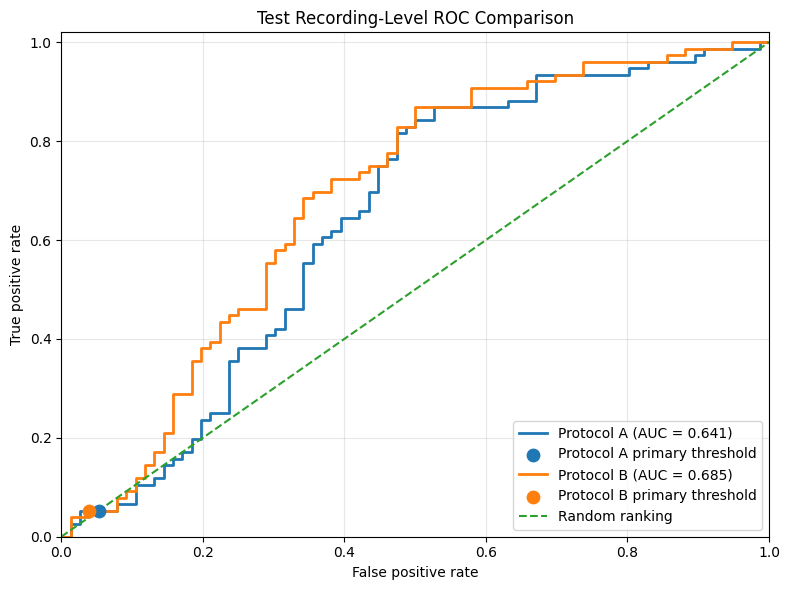

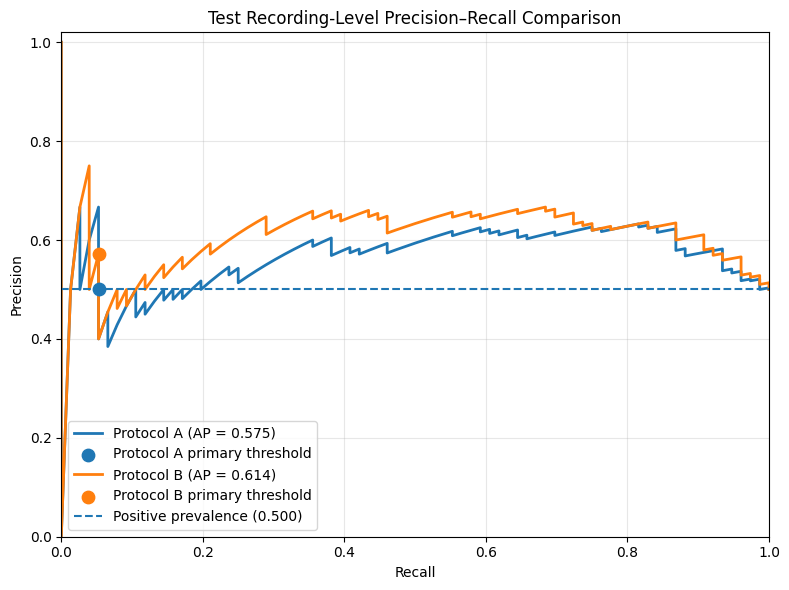

,Protocol,Test ROC-AUC,Test PR-AUC,Primary threshold,Primary FPR,Primary recall,Primary precision
0,A,0.6413,0.5751,0.339208,0.0526,0.0526,0.5000
1,B,0.6851,0.6138,0.307567,0.0395,0.0526,0.5714


Test ROC and precision–recall comparisons completed. All marked thresholds were selected from validation data.


In [20]:
# ==========================================================
# 12.7 Compare Test ROC and Precision–Recall Curves
# ==========================================================
# Compare Protocol A and B using continuous recording scores.
# Primary operating points use thresholds fixed on validation.

def validate_curve_data(labels, scores, protocol):
    """Validate binary labels and continuous anomaly scores."""
    if len(labels) != len(scores):
        raise ValueError(
            f"Protocol {protocol}: label and score counts differ."
        )

    if set(np.unique(labels)) != {0, 1}:
        raise ValueError(
            f"Protocol {protocol}: test data must contain Normal and AF."
        )

    if not np.isfinite(scores).all():
        raise ValueError(
            f"Protocol {protocol}: anomaly scores contain NaN or Inf."
        )


def get_operating_point(labels, scores, threshold):
    """Return ROC- and PR-space coordinates for one threshold."""
    predicted = (scores >= threshold).astype(np.int64)
    tn, fp, fn, tp = confusion_matrix(
        labels,
        predicted,
        labels=[0, 1],
    ).ravel()

    recall = tp / max(tp + fn, 1)

    return {
        "fpr": fp / max(fp + tn, 1),
        "recall": recall,
        "precision": tp / max(tp + fp, 1),
    }


curve_results = {}
curve_summary_rows = []

for protocol in RUN_PROTOCOLS:
    predictions = protocol_data[protocol]["test_predictions"]

    labels = predictions["AF"].to_numpy(dtype=np.int64)
    scores = predictions["recording_score"].to_numpy(dtype=np.float64)
    threshold = threshold_results[protocol]["primary_threshold"]

    validate_curve_data(labels, scores, protocol)

    fpr, tpr, _ = roc_curve(labels, scores)
    precision, recall, _ = precision_recall_curve(labels, scores)

    roc_auc = roc_auc_score(labels, scores)
    pr_auc = average_precision_score(labels, scores)
    operating_point = get_operating_point(
        labels,
        scores,
        threshold,
    )

    curve_results[protocol] = {
        "labels": labels,
        "fpr": fpr,
        "tpr": tpr,
        "precision": precision,
        "recall": recall,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "primary_threshold": threshold,
        "operating_point": operating_point,
    }

    curve_summary_rows.append({
        "Protocol": protocol,
        "Test ROC-AUC": roc_auc,
        "Test PR-AUC": pr_auc,
        "Primary threshold": threshold,
        "Primary FPR": operating_point["fpr"],
        "Primary recall": operating_point["recall"],
        "Primary precision": operating_point["precision"],
    })


figure_dir = OUTPUT_ROOT / "comparison_figures"
figure_dir.mkdir(parents=True, exist_ok=True)


# ----------------------------------------------------------
# Test ROC comparison
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

for protocol in RUN_PROTOCOLS:
    result = curve_results[protocol]
    point = result["operating_point"]

    ax.plot(
        result["fpr"],
        result["tpr"],
        linewidth=2,
        label=(
            f"Protocol {protocol} "
            f"(AUC = {result['roc_auc']:.3f})"
        ),
    )

    ax.scatter(
        point["fpr"],
        point["recall"],
        s=80,
        zorder=5,
        label=f"Protocol {protocol} primary threshold",
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random ranking",
)

ax.set(
    title="Test Recording-Level ROC Comparison",
    xlabel="False positive rate",
    ylabel="True positive rate",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")

fig.tight_layout()

roc_path = figure_dir / "protocol_A_B_test_roc_comparison.png"
fig.savefig(roc_path, dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)


# ----------------------------------------------------------
# Test precision–recall comparison
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

for protocol in RUN_PROTOCOLS:
    result = curve_results[protocol]
    point = result["operating_point"]
    prevalence = result["labels"].mean()

    ax.plot(
        result["recall"],
        result["precision"],
        linewidth=2,
        label=(
            f"Protocol {protocol} "
            f"(AP = {result['pr_auc']:.3f})"
        ),
    )

    ax.scatter(
        point["recall"],
        point["precision"],
        s=80,
        zorder=5,
        label=f"Protocol {protocol} primary threshold",
    )

# Both test sets are balanced; the first prevalence is sufficient.
baseline = curve_results[RUN_PROTOCOLS[0]]["labels"].mean()

ax.axhline(
    baseline,
    linestyle="--",
    linewidth=1.5,
    label=f"Positive prevalence ({baseline:.3f})",
)

ax.set(
    title="Test Recording-Level Precision–Recall Comparison",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
ax.grid(alpha=0.3)
ax.legend(loc="lower left")

fig.tight_layout()

pr_path = figure_dir / "protocol_A_B_test_pr_comparison.png"
fig.savefig(pr_path, dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)


# ----------------------------------------------------------
# Concise comparison summary
# ----------------------------------------------------------
curve_comparison_summary = pd.DataFrame(curve_summary_rows)

display(
    curve_comparison_summary.round({
        "Test ROC-AUC": 4,
        "Test PR-AUC": 4,
        "Primary threshold": 6,
        "Primary FPR": 4,
        "Primary recall": 4,
        "Primary precision": 4,
    })
)

print(
    "Test ROC and precision–recall comparisons completed. "
    "All marked thresholds were selected from validation data."
)

# 12.8 Analyze Recording-Level Score Distributions

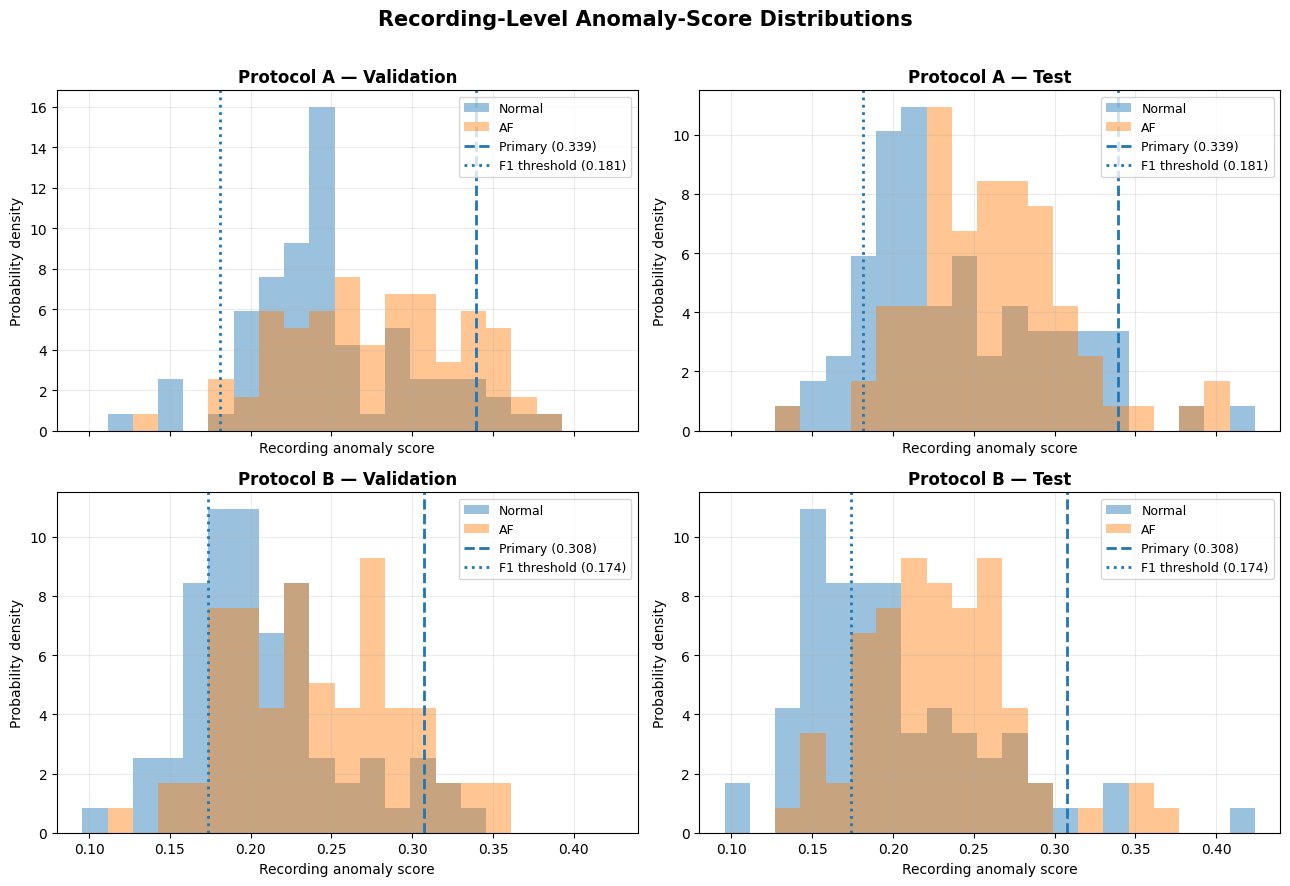

,Protocol,Split,Class,Count,Mean,Median,Std,Minimum,Maximum,Above primary (%),Above F1 (%)
0,A,Validation,Normal,76,0.247877,0.239834,0.050934,0.123693,0.379332,5.26,93.42
1,A,Validation,AF,76,0.276696,0.275754,0.053813,0.137237,0.392584,13.16,98.68
2,A,Test,Normal,76,0.239780,0.220274,0.058008,0.136523,0.417005,5.26,90.79
3,A,Test,AF,76,0.261345,0.259348,0.047867,0.141980,0.398694,5.26,97.37
4,B,Validation,Normal,76,0.208243,0.198529,0.047935,0.100176,0.332247,5.26,77.63
5,B,Validation,AF,76,0.240444,0.236269,0.051625,0.124898,0.361150,9.21,94.74
6,B,Test,Normal,76,0.199747,0.184825,0.056696,0.106854,0.419482,3.95,60.53
7,B,Test,AF,76,0.227800,0.224028,0.046126,0.136342,0.363426,5.26,90.79


Recording-score distributions compared for both protocols. Figure saved to: /kaggle/working/outputs/comparison_figures/protocol_A_B_recording_score_distributions.png


In [21]:
# ==========================================================
# 12.8 Analyze Recording-Level Score Distributions
# ==========================================================
# Compare Normal and AF recording scores for both protocols.
# Thresholds were fixed previously and are not changed here.

distribution_rows = []
distribution_data = {}

splits = {
    "Validation": "valid_recording_scores",
    "Test": "test_recording_scores",
}

for protocol in RUN_PROTOCOLS:
    distribution_data[protocol] = {}

    for split_name, data_key in splits.items():
        scores_df = protocol_data[protocol][data_key].copy()

        required = {"ecg_id", "AF", "recording_score"}
        missing = required - set(scores_df.columns)

        if missing:
            raise KeyError(
                f"Protocol {protocol} {split_name}: "
                f"missing columns {sorted(missing)}."
            )

        if not scores_df["ecg_id"].is_unique:
            raise ValueError(
                f"Protocol {protocol} {split_name}: "
                "expected one score per ECG recording."
            )

        if not scores_df["AF"].isin([0, 1]).all():
            raise ValueError(
                f"Protocol {protocol} {split_name}: invalid AF labels."
            )

        if not np.isfinite(scores_df["recording_score"]).all():
            raise ValueError(
                f"Protocol {protocol} {split_name}: invalid scores."
            )

        distribution_data[protocol][split_name] = scores_df

        primary_threshold = threshold_results[protocol][
            "primary_threshold"
        ]
        f1_threshold = threshold_results[protocol]["f1_threshold"]

        for label, class_name in [(0, "Normal"), (1, "AF")]:
            class_scores = scores_df.loc[
                scores_df["AF"].eq(label),
                "recording_score",
            ]

            distribution_rows.append({
                "Protocol": protocol,
                "Split": split_name,
                "Class": class_name,
                "Count": len(class_scores),
                "Mean": class_scores.mean(),
                "Median": class_scores.median(),
                "Std": class_scores.std(),
                "Minimum": class_scores.min(),
                "Maximum": class_scores.max(),
                "Above primary (%)": (
                    100 * class_scores.ge(primary_threshold).mean()
                ),
                "Above F1 (%)": (
                    100 * class_scores.ge(f1_threshold).mean()
                ),
            })


# ----------------------------------------------------------
# Shared score range and bins
# ----------------------------------------------------------
all_scores = np.concatenate([
    distribution_data[protocol][split]["recording_score"].to_numpy()
    for protocol in RUN_PROTOCOLS
    for split in splits
])

score_min = max(0.0, all_scores.min() - 0.02)
score_max = all_scores.max() + 0.02
bins = np.linspace(score_min, score_max, 24)


# ----------------------------------------------------------
# Combined validation/test distribution figure
# ----------------------------------------------------------
fig, axes = plt.subplots(
    nrows=len(RUN_PROTOCOLS),
    ncols=2,
    figsize=(13, 4.5 * len(RUN_PROTOCOLS)),
    sharex=True,
)

axes = np.atleast_2d(axes)

for row, protocol in enumerate(RUN_PROTOCOLS):
    primary_threshold = threshold_results[protocol][
        "primary_threshold"
    ]
    f1_threshold = threshold_results[protocol]["f1_threshold"]

    for column, split_name in enumerate(splits):
        ax = axes[row, column]
        scores_df = distribution_data[protocol][split_name]

        normal_scores = scores_df.loc[
            scores_df["AF"].eq(0),
            "recording_score",
        ]
        af_scores = scores_df.loc[
            scores_df["AF"].eq(1),
            "recording_score",
        ]

        ax.hist(
            normal_scores,
            bins=bins,
            density=True,
            alpha=0.45,
            label="Normal",
        )

        ax.hist(
            af_scores,
            bins=bins,
            density=True,
            alpha=0.45,
            label="AF",
        )

        ax.axvline(
            primary_threshold,
            linestyle="--",
            linewidth=2,
            label=f"Primary ({primary_threshold:.3f})",
        )

        ax.axvline(
            f1_threshold,
            linestyle=":",
            linewidth=2,
            label=f"F1 threshold ({f1_threshold:.3f})",
        )

        ax.set_title(
            f"Protocol {protocol} — {split_name}",
            fontsize=12,
            fontweight="bold",
        )
        ax.set_xlabel("Recording anomaly score")
        ax.set_ylabel("Probability density")
        ax.set_xlim(score_min, score_max)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)

fig.suptitle(
    "Recording-Level Anomaly-Score Distributions",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

figure_dir = OUTPUT_ROOT / "comparison_figures"
figure_dir.mkdir(parents=True, exist_ok=True)

distribution_figure_path = (
    figure_dir
    / "protocol_A_B_recording_score_distributions.png"
)

fig.savefig(
    distribution_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ----------------------------------------------------------
# Concise descriptive summary
# ----------------------------------------------------------
score_distribution_summary = pd.DataFrame(distribution_rows)

display(
    score_distribution_summary.round({
        "Mean": 6,
        "Median": 6,
        "Std": 6,
        "Minimum": 6,
        "Maximum": 6,
        "Above primary (%)": 2,
        "Above F1 (%)": 2,
    })
)

summary_path = (
    OUTPUT_ROOT
    / "protocol_comparison_score_distribution_summary.csv"
)

score_distribution_summary.to_csv(
    summary_path,
    index=False,
)

print(
    "Recording-score distributions compared for both protocols. "
    f"Figure saved to: {distribution_figure_path}"
)

# 12.9 Validation Threshold Sensitivity Analysis

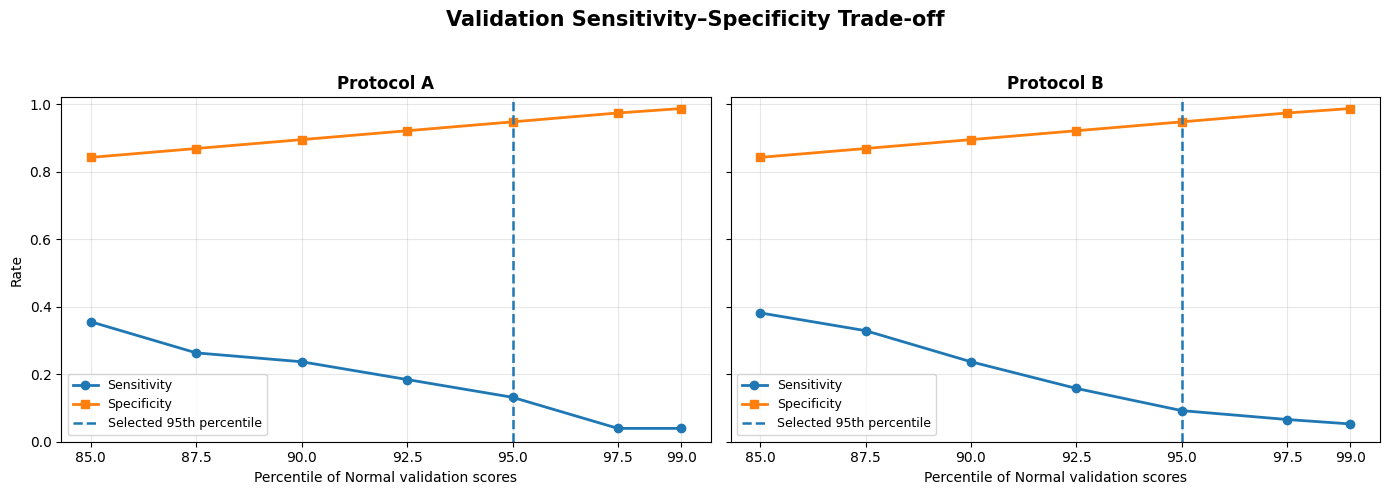

,Protocol,Percentile,Threshold,Precision,Sensitivity,Specificity,F1-score,Balanced accuracy,Predicted anomaly rate (%)
0,A,85.0,0.302000,0.6923,0.3553,0.8421,0.4696,0.5987,25.66
1,A,87.5,0.316068,0.6667,0.2632,0.8684,0.3774,0.5658,19.74
2,A,90.0,0.324253,0.6923,0.2368,0.8947,0.3529,0.5658,17.11
3,A,92.5,0.332549,0.7000,0.1842,0.9211,0.2917,0.5526,13.16
4,A,95.0,0.339208,0.7143,0.1316,0.9474,0.2222,0.5395,9.21
5,A,97.5,0.360964,0.6000,0.0395,0.9737,0.0741,0.5066,3.29
6,A,99.0,0.366557,0.7500,0.0395,0.9868,0.0750,0.5132,2.63
7,B,85.0,0.256853,0.7073,0.3816,0.8421,0.4957,0.6118,26.97
8,B,87.5,0.272111,0.7143,0.3289,0.8684,0.4505,0.5987,23.03
9,B,90.0,0.279834,0.6923,0.2368,0.8947,0.3529,0.5658,17.11


Threshold sensitivity was evaluated using validation data only. The previously selected 95th-percentile thresholds remain unchanged.


In [22]:
# ==========================================================
# 12.9 Validation Threshold Sensitivity Analysis
# ==========================================================
# Examine how percentile-based unsupervised thresholds affect
# validation performance. The primary 95th-percentile
# threshold remains unchanged.

THRESHOLD_PERCENTILES = [85, 87.5, 90, 92.5, 95, 97.5, 99]


def evaluate_percentile_threshold(labels, scores, threshold):
    """Evaluate one fixed recording-level anomaly threshold."""
    predicted = (scores >= threshold).astype(np.int64)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predicted,
        labels=[0, 1],
    ).ravel()

    return {
        "Threshold": float(threshold),
        "Precision": precision_score(
            labels,
            predicted,
            zero_division=0,
        ),
        "Sensitivity": recall_score(
            labels,
            predicted,
            zero_division=0,
        ),
        "Specificity": tn / max(tn + fp, 1),
        "F1-score": f1_score(
            labels,
            predicted,
            zero_division=0,
        ),
        "Balanced accuracy": balanced_accuracy_score(
            labels,
            predicted,
        ),
        "Predicted anomaly rate (%)": 100 * predicted.mean(),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


threshold_sensitivity = {}
sensitivity_rows = []

for protocol in RUN_PROTOCOLS:
    validation_scores = protocol_data[protocol][
        "valid_recording_scores"
    ]

    labels = validation_scores["AF"].to_numpy(dtype=np.int64)
    scores = validation_scores[
        "recording_score"
    ].to_numpy(dtype=np.float64)

    normal_scores = validation_scores.loc[
        validation_scores["AF"].eq(0),
        "recording_score",
    ].to_numpy(dtype=np.float64)

    if set(np.unique(labels)) != {0, 1}:
        raise ValueError(
            f"Protocol {protocol}: validation must contain Normal and AF."
        )

    if not np.isfinite(scores).all():
        raise ValueError(
            f"Protocol {protocol}: validation scores contain NaN or Inf."
        )

    protocol_rows = []

    for percentile in THRESHOLD_PERCENTILES:
        threshold = float(
            np.percentile(normal_scores, percentile)
        )

        metrics = evaluate_percentile_threshold(
            labels,
            scores,
            threshold,
        )

        row = {
            "Protocol": protocol,
            "Percentile": percentile,
            **metrics,
        }

        protocol_rows.append(row)
        sensitivity_rows.append(row)

    protocol_df = pd.DataFrame(protocol_rows)
    threshold_sensitivity[protocol] = protocol_df

    # Confirm that the diagnostic 95th percentile matches
    # the primary threshold selected in Section 12.4.
    calculated_primary = float(
        protocol_df.loc[
            protocol_df["Percentile"].eq(
                THRESHOLD_PERCENTILE
            ),
            "Threshold",
        ].iloc[0]
    )

    saved_primary = threshold_results[protocol][
        "primary_threshold"
    ]

    if not np.isclose(
        calculated_primary,
        saved_primary,
        rtol=1e-10,
        atol=1e-12,
    ):
        raise RuntimeError(
            f"Protocol {protocol}: 95th-percentile threshold mismatch."
        )

    output_dir = (
        OUTPUT_ROOT
        / f"protocol_{protocol}"
        / "threshold_sensitivity"
    )
    output_dir.mkdir(parents=True, exist_ok=True)

    protocol_df.to_csv(
        output_dir
        / f"protocol_{protocol}_validation_threshold_sensitivity.csv",
        index=False,
    )


threshold_sensitivity_summary = pd.DataFrame(
    sensitivity_rows
)


# ----------------------------------------------------------
# Combined sensitivity–specificity figure
# ----------------------------------------------------------
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(RUN_PROTOCOLS),
    figsize=(7 * len(RUN_PROTOCOLS), 5),
    sharey=True,
)

axes = np.atleast_1d(axes)

for ax, protocol in zip(axes, RUN_PROTOCOLS):
    protocol_df = threshold_sensitivity[protocol]

    ax.plot(
        protocol_df["Percentile"],
        protocol_df["Sensitivity"],
        marker="o",
        linewidth=2,
        label="Sensitivity",
    )

    ax.plot(
        protocol_df["Percentile"],
        protocol_df["Specificity"],
        marker="s",
        linewidth=2,
        label="Specificity",
    )

    ax.axvline(
        THRESHOLD_PERCENTILE,
        linestyle="--",
        linewidth=1.8,
        label=f"Selected {THRESHOLD_PERCENTILE:g}th percentile",
    )

    ax.set_title(
        f"Protocol {protocol}",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Percentile of Normal validation scores")
    ax.set_xticks(THRESHOLD_PERCENTILES)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Rate")

fig.suptitle(
    "Validation Sensitivity–Specificity Trade-off",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

figure_dir = OUTPUT_ROOT / "comparison_figures"
figure_dir.mkdir(parents=True, exist_ok=True)

sensitivity_figure_path = (
    figure_dir
    / "protocol_A_B_threshold_sensitivity.png"
)

fig.savefig(
    sensitivity_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ----------------------------------------------------------
# Concise sensitivity table
# ----------------------------------------------------------
display_columns = [
    "Protocol",
    "Percentile",
    "Threshold",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1-score",
    "Balanced accuracy",
    "Predicted anomaly rate (%)",
]

display(
    threshold_sensitivity_summary[
        display_columns
    ].round({
        "Threshold": 6,
        "Precision": 4,
        "Sensitivity": 4,
        "Specificity": 4,
        "F1-score": 4,
        "Balanced accuracy": 4,
        "Predicted anomaly rate (%)": 2,
    })
)

print(
    "Threshold sensitivity was evaluated using validation data only. "
    "The previously selected 95th-percentile thresholds remain unchanged."
)

# 12.10 Qualitative Analysis of Representative Predictions

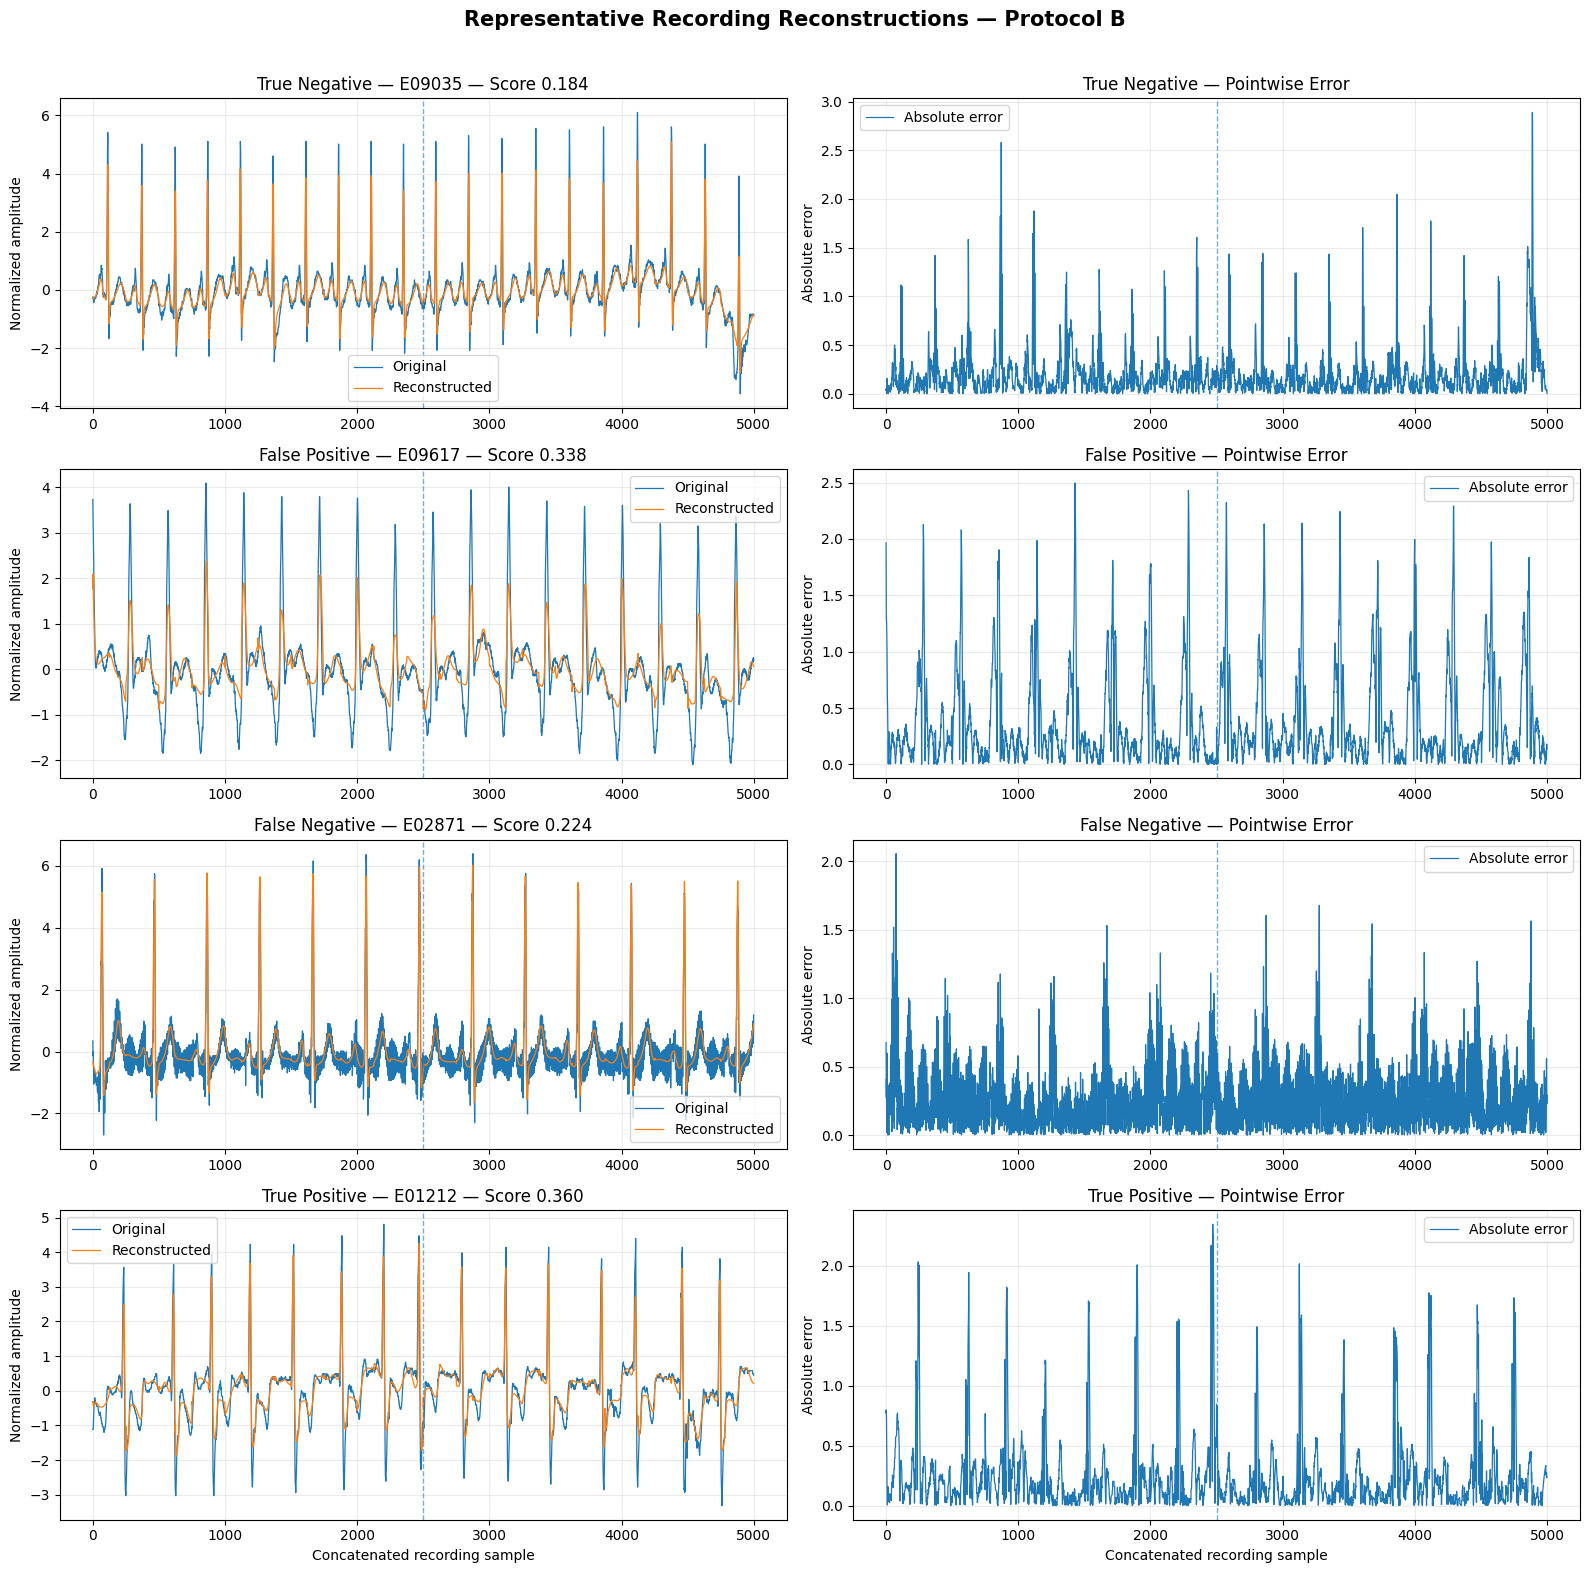

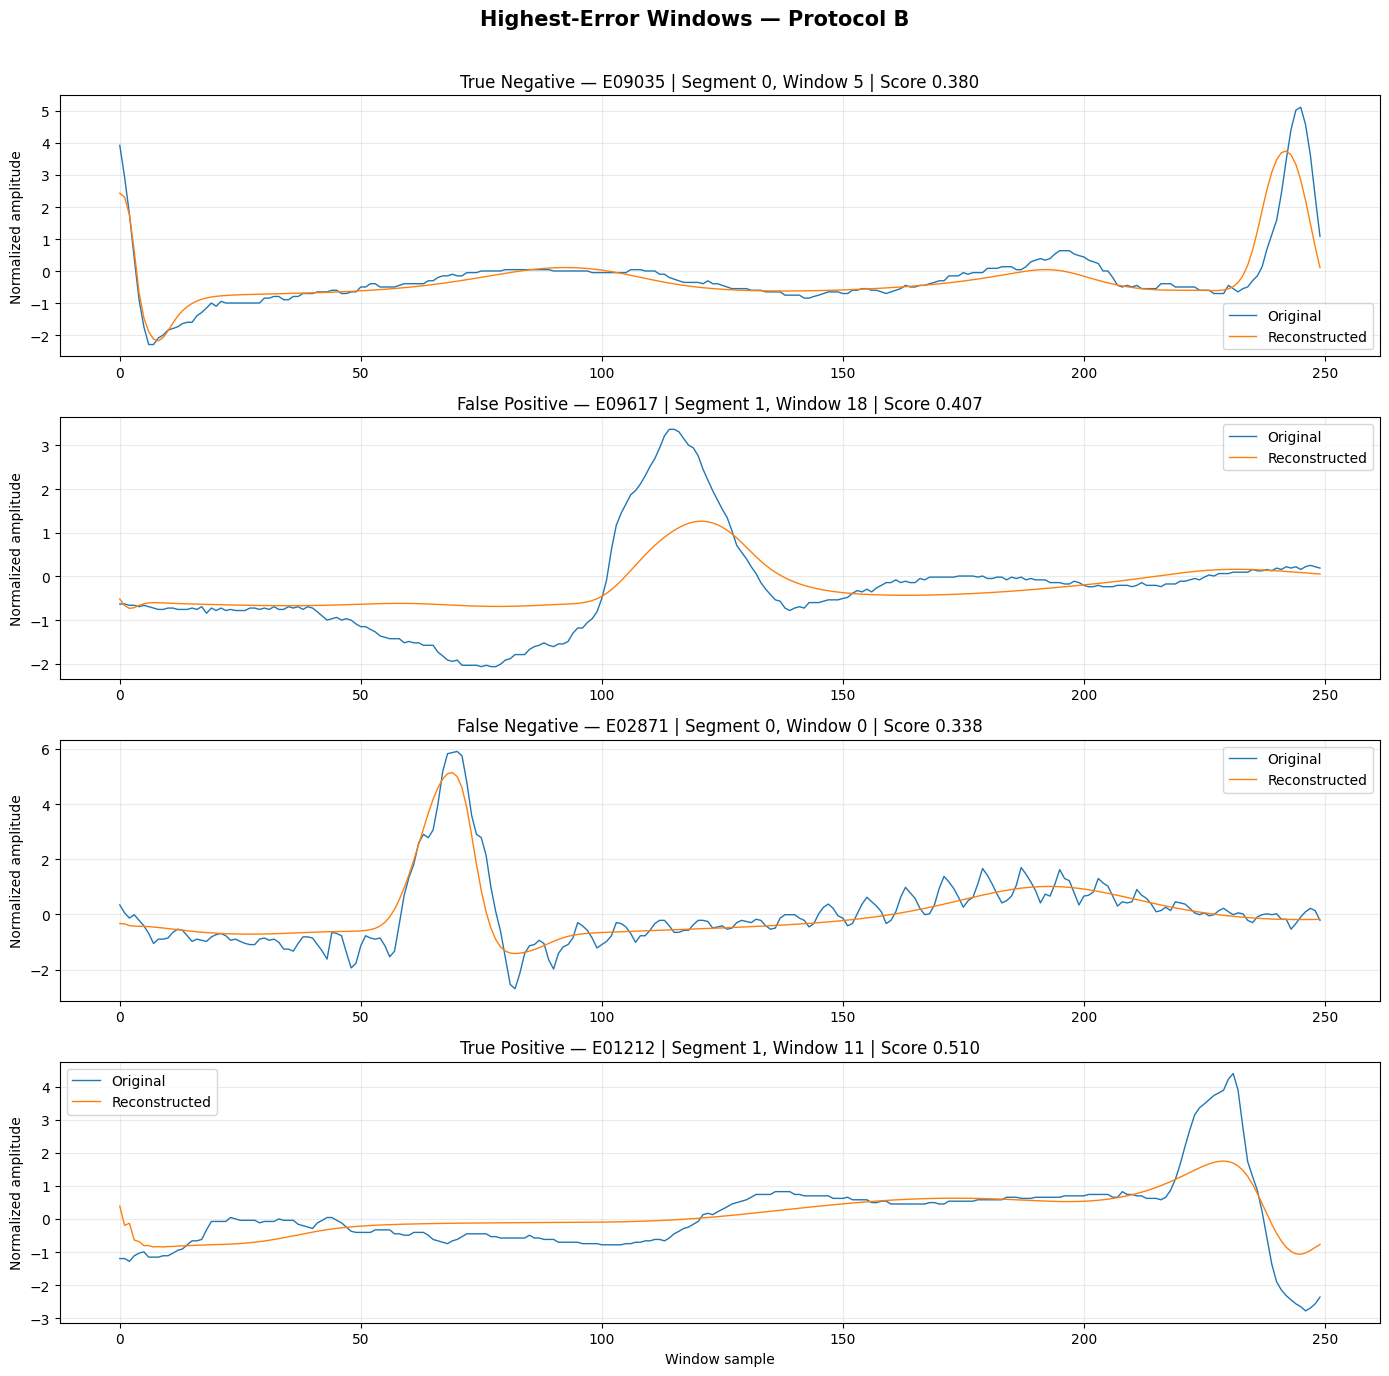

,Outcome,ECG ID,Ground truth,Primary prediction,Recording score,Primary threshold,Score - threshold,F1 prediction,Segments,Windows,Highest window score
0,True Negative,E09035,Normal,Normal,0.183888,0.307567,-0.123679,Anomalous,2,38,0.380480
1,False Positive,E09617,Normal,Anomalous,0.337960,0.307567,0.030393,Anomalous,2,38,0.406762
2,False Negative,E02871,AF,Normal,0.223728,0.307567,-0.083839,Anomalous,2,38,0.337678
3,True Positive,E01212,AF,Anomalous,0.359856,0.307567,0.052289,Anomalous,2,38,0.510421


Qualitative analysis completed for Protocol B, selected by test ROC-AUC (0.6851).


In [23]:
# ==========================================================
# 12.10 Qualitative Analysis of Representative Predictions
# ==========================================================
# Inspect one representative TN, FP, FN, and TP from the
# better-ranked protocol. Selection uses the median score
# within each outcome group to avoid extreme examples.

QUALITATIVE_LEAD_INDEX = 0
OUTCOMES = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive",
]

# Qualitative inspection is descriptive only; it does not
# modify models, thresholds, or reported test metrics.
QUALITATIVE_PROTOCOL = max(
    RUN_PROTOCOLS,
    key=lambda protocol: evaluation_results[protocol]["roc_auc"],
)

protocol = QUALITATIVE_PROTOCOL
data = protocol_data[protocol]
model = evaluation_models[protocol]["model"]
predictions = data["test_predictions"].copy()
window_df = data["test_lstm_df"]

aggregation = aggregation_results[protocol]["configuration"]
primary_threshold = threshold_results[protocol]["primary_threshold"]
f1_threshold = threshold_results[protocol]["f1_threshold"]
selected_score = aggregation["score_name"]

if "primary_outcome" not in predictions:
    raise KeyError(
        "Run Section 12.6 before qualitative analysis."
    )

if not 0 <= QUALITATIVE_LEAD_INDEX < N_LEADS:
    raise ValueError("Invalid qualitative lead index.")


def select_representative(prediction_df, outcome):
    """Select the score closest to the outcome-group median."""
    group = prediction_df.loc[
        prediction_df["primary_outcome"].eq(outcome)
    ].copy()

    if group.empty:
        return None

    median_score = group["recording_score"].median()

    return (
        group.assign(
            distance=(group["recording_score"] - median_score).abs()
        )
        .sort_values(["distance", "ecg_id"])
        .iloc[0]
    )


def compute_window_scores(original, reconstructed):
    """Compute supported reconstruction errors per window."""
    difference = reconstructed - original

    return {
        "mae": difference.abs().mean(dim=(1, 2)),
        "mse": difference.square().mean(dim=(1, 2)),
        "smooth_l1": torch.nn.functional.smooth_l1_loss(
            reconstructed,
            original,
            beta=SMOOTH_L1_BETA,
            reduction="none",
        ).mean(dim=(1, 2)),
    }


def overlap_average(rows, original, reconstructed):
    """Rebuild complete segments by averaging overlaps."""
    segment_originals = []
    segment_reconstructions = []

    for segment_id in rows["segment_id"].drop_duplicates():
        mask = rows["segment_id"].eq(segment_id).to_numpy()
        positions = np.flatnonzero(mask)

        segment_rows = (
            rows.loc[mask]
            .sort_values("window_id")
            .reset_index(drop=True)
        )

        segment_length = int(segment_rows["end_sample"].max())

        original_sum = np.zeros(
            (segment_length, N_LEADS),
            dtype=np.float64,
        )
        reconstruction_sum = np.zeros_like(original_sum)
        counts = np.zeros(segment_length, dtype=np.float64)

        for local_index, row in segment_rows.iterrows():
            start = int(row["start_sample"])
            end = int(row["end_sample"])

            original_sum[start:end] += original[
                positions[local_index]
            ]
            reconstruction_sum[start:end] += reconstructed[
                positions[local_index]
            ]
            counts[start:end] += 1

        if (counts == 0).any():
            raise RuntimeError(
                f"Segment {segment_id} contains uncovered samples."
            )

        segment_originals.append(
            original_sum / counts[:, None]
        )
        segment_reconstructions.append(
            reconstruction_sum / counts[:, None]
        )

    return (
        np.concatenate(segment_originals).astype(np.float32),
        np.concatenate(segment_reconstructions).astype(np.float32),
        np.cumsum([len(segment) for segment in segment_originals]),
    )


def analyze_recording(prediction_row):
    """Reconstruct and verify one complete ECG recording."""
    ecg_id = prediction_row["ecg_id"]

    rows = (
        window_df.loc[window_df["ecg_id"].eq(ecg_id)]
        .sort_values(["segment_id", "window_id"])
        .reset_index(drop=True)
    )

    if rows.empty:
        raise ValueError(f"No windows found for ECG {ecg_id}.")

    original_tensor = torch.from_numpy(
        np.stack(rows["ecg"].to_numpy())
    ).to(
        DEVICE,
        dtype=torch.float32,
    )

    model.eval()

    with torch.inference_mode():
        reconstructed_tensor = model(original_tensor)

    if reconstructed_tensor.shape != original_tensor.shape:
        raise RuntimeError(
            f"ECG {ecg_id}: reconstruction shape mismatch."
        )

    score_tensors = compute_window_scores(
        original_tensor,
        reconstructed_tensor,
    )

    window_scores = rows[
        [
            "ecg_id",
            "segment_id",
            "AF",
            "window_id",
            "start_sample",
            "end_sample",
        ]
    ].copy()

    for score_name, values in score_tensors.items():
        window_scores[score_name] = values.cpu().numpy()

    # Verify the independently reconstructed recording score.
    _, recording_score_df = build_recording_scores(
        window_df=window_scores,
        score_name=selected_score,
        window_to_segment=aggregation["window_to_segment"],
        segment_to_recording=aggregation["segment_to_recording"],
    )

    recomputed_score = float(
        recording_score_df["recording_score"].iloc[0]
    )
    saved_score = float(prediction_row["recording_score"])

    if not np.isclose(
        recomputed_score,
        saved_score,
        rtol=1e-5,
        atol=1e-7,
    ):
        raise RuntimeError(
            f"ECG {ecg_id}: recomputed score does not match saved score."
        )

    original_windows = original_tensor.cpu().numpy()
    reconstructed_windows = reconstructed_tensor.cpu().numpy()

    original_recording, reconstructed_recording, boundaries = (
        overlap_average(
            rows,
            original_windows,
            reconstructed_windows,
        )
    )

    selected_window_scores = window_scores[
        selected_score
    ].to_numpy()

    highest_position = int(np.argmax(selected_window_scores))
    highest_metadata = window_scores.iloc[highest_position]

    return {
        "ecg_id": ecg_id,
        "ground_truth": int(prediction_row["AF"]),
        "prediction": int(prediction_row["prediction_primary"]),
        "recording_score": recomputed_score,
        "original_recording": original_recording,
        "reconstructed_recording": reconstructed_recording,
        "boundaries": boundaries,
        "highest_original": original_windows[highest_position],
        "highest_reconstructed": reconstructed_windows[highest_position],
        "highest_segment": highest_metadata["segment_id"],
        "highest_window": int(highest_metadata["window_id"]),
        "highest_score": float(
            selected_window_scores[highest_position]
        ),
        "number_of_segments": rows["segment_id"].nunique(),
        "number_of_windows": len(rows),
        "window_scores": window_scores,
    }


representatives = {
    outcome: select_representative(predictions, outcome)
    for outcome in OUTCOMES
}

analysis_results = {}

for outcome, selected_row in representatives.items():
    if selected_row is not None:
        analysis_results[outcome] = analyze_recording(selected_row)

if not analysis_results:
    raise RuntimeError("No qualitative outcomes were available.")


# ----------------------------------------------------------
# Complete-recording reconstruction comparison
# ----------------------------------------------------------
fig, axes = plt.subplots(
    nrows=len(analysis_results),
    ncols=2,
    figsize=(16, 4 * len(analysis_results)),
)

axes = np.atleast_2d(axes)

for row_index, (outcome, result) in enumerate(
    analysis_results.items()
):
    original = result["original_recording"][
        :, QUALITATIVE_LEAD_INDEX
    ]
    reconstructed = result["reconstructed_recording"][
        :, QUALITATIVE_LEAD_INDEX
    ]
    absolute_error = np.abs(original - reconstructed)

    reconstruction_ax = axes[row_index, 0]
    error_ax = axes[row_index, 1]

    reconstruction_ax.plot(
        original,
        linewidth=0.9,
        label="Original",
    )
    reconstruction_ax.plot(
        reconstructed,
        linewidth=0.9,
        label="Reconstructed",
    )

    error_ax.plot(
        absolute_error,
        linewidth=0.9,
        label="Absolute error",
    )

    for boundary in result["boundaries"][:-1]:
        reconstruction_ax.axvline(
            boundary,
            linestyle="--",
            linewidth=1,
            alpha=0.6,
        )
        error_ax.axvline(
            boundary,
            linestyle="--",
            linewidth=1,
            alpha=0.6,
        )

    title = (
        f"{outcome} — {result['ecg_id']} — "
        f"Score {result['recording_score']:.3f}"
    )

    reconstruction_ax.set_title(title)
    error_ax.set_title(f"{outcome} — Pointwise Error")

    reconstruction_ax.set_ylabel("Normalized amplitude")
    error_ax.set_ylabel("Absolute error")

    reconstruction_ax.grid(alpha=0.25)
    error_ax.grid(alpha=0.25)
    reconstruction_ax.legend()
    error_ax.legend()

axes[-1, 0].set_xlabel("Concatenated recording sample")
axes[-1, 1].set_xlabel("Concatenated recording sample")

fig.suptitle(
    f"Representative Recording Reconstructions — Protocol {protocol}",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.97])


# ----------------------------------------------------------
# Highest-error-window comparison
# ----------------------------------------------------------
fig_windows, window_axes = plt.subplots(
    nrows=len(analysis_results),
    ncols=1,
    figsize=(14, 3.5 * len(analysis_results)),
)

window_axes = np.atleast_1d(window_axes)

for ax, (outcome, result) in zip(
    window_axes,
    analysis_results.items(),
):
    ax.plot(
        result["highest_original"][:, QUALITATIVE_LEAD_INDEX],
        linewidth=1,
        label="Original",
    )
    ax.plot(
        result["highest_reconstructed"][:, QUALITATIVE_LEAD_INDEX],
        linewidth=1,
        label="Reconstructed",
    )

    ax.set_title(
        f"{outcome} — {result['ecg_id']} | "
        f"Segment {result['highest_segment']}, "
        f"Window {result['highest_window']} | "
        f"Score {result['highest_score']:.3f}"
    )
    ax.set_ylabel("Normalized amplitude")
    ax.grid(alpha=0.25)
    ax.legend()

window_axes[-1].set_xlabel("Window sample")

fig_windows.suptitle(
    f"Highest-Error Windows — Protocol {protocol}",
    fontsize=15,
    fontweight="bold",
)

fig_windows.tight_layout(rect=[0, 0, 1, 0.97])


# ----------------------------------------------------------
# Save figures and numerical summaries
# ----------------------------------------------------------
output_dir = (
    OUTPUT_ROOT
    / f"protocol_{protocol}"
    / "qualitative_analysis"
)
figure_dir = (
    OUTPUT_ROOT
    / f"protocol_{protocol}"
    / "figures"
    / "qualitative_analysis"
)

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

recording_figure_path = (
    figure_dir
    / f"protocol_{protocol}_representative_recordings.png"
)
window_figure_path = (
    figure_dir
    / f"protocol_{protocol}_highest_error_windows.png"
)

fig.savefig(
    recording_figure_path,
    dpi=300,
    bbox_inches="tight",
)
fig_windows.savefig(
    window_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)
plt.show()
plt.close(fig_windows)

summary_rows = []

for outcome, result in analysis_results.items():
    result["window_scores"].to_csv(
        output_dir
        / f"{outcome.lower().replace(' ', '_')}_window_scores.csv",
        index=False,
    )

    summary_rows.append({
        "Outcome": outcome,
        "ECG ID": result["ecg_id"],
        "Ground truth": (
            "AF" if result["ground_truth"] else "Normal"
        ),
        "Primary prediction": (
            "Anomalous" if result["prediction"] else "Normal"
        ),
        "Recording score": result["recording_score"],
        "Primary threshold": primary_threshold,
        "Score - threshold": (
            result["recording_score"] - primary_threshold
        ),
        "F1 prediction": (
            "Anomalous"
            if result["recording_score"] >= f1_threshold
            else "Normal"
        ),
        "Segments": result["number_of_segments"],
        "Windows": result["number_of_windows"],
        "Highest window score": result["highest_score"],
    })


qualitative_summary = pd.DataFrame(summary_rows)

qualitative_summary.to_csv(
    output_dir
    / f"protocol_{protocol}_representative_prediction_summary.csv",
    index=False,
)

display(
    qualitative_summary.round({
        "Recording score": 6,
        "Primary threshold": 6,
        "Score - threshold": 6,
        "Highest window score": 6,
    })
)

missing_outcomes = [
    outcome
    for outcome in OUTCOMES
    if outcome not in analysis_results
]

if missing_outcomes:
    print(
        "Unavailable outcomes: "
        + ", ".join(missing_outcomes)
    )

print(
    f"Qualitative analysis completed for Protocol {protocol}, "
    f"selected by test ROC-AUC ({evaluation_results[protocol]['roc_auc']:.4f})."
)

# 12.11 Unified Single-Recording Inference

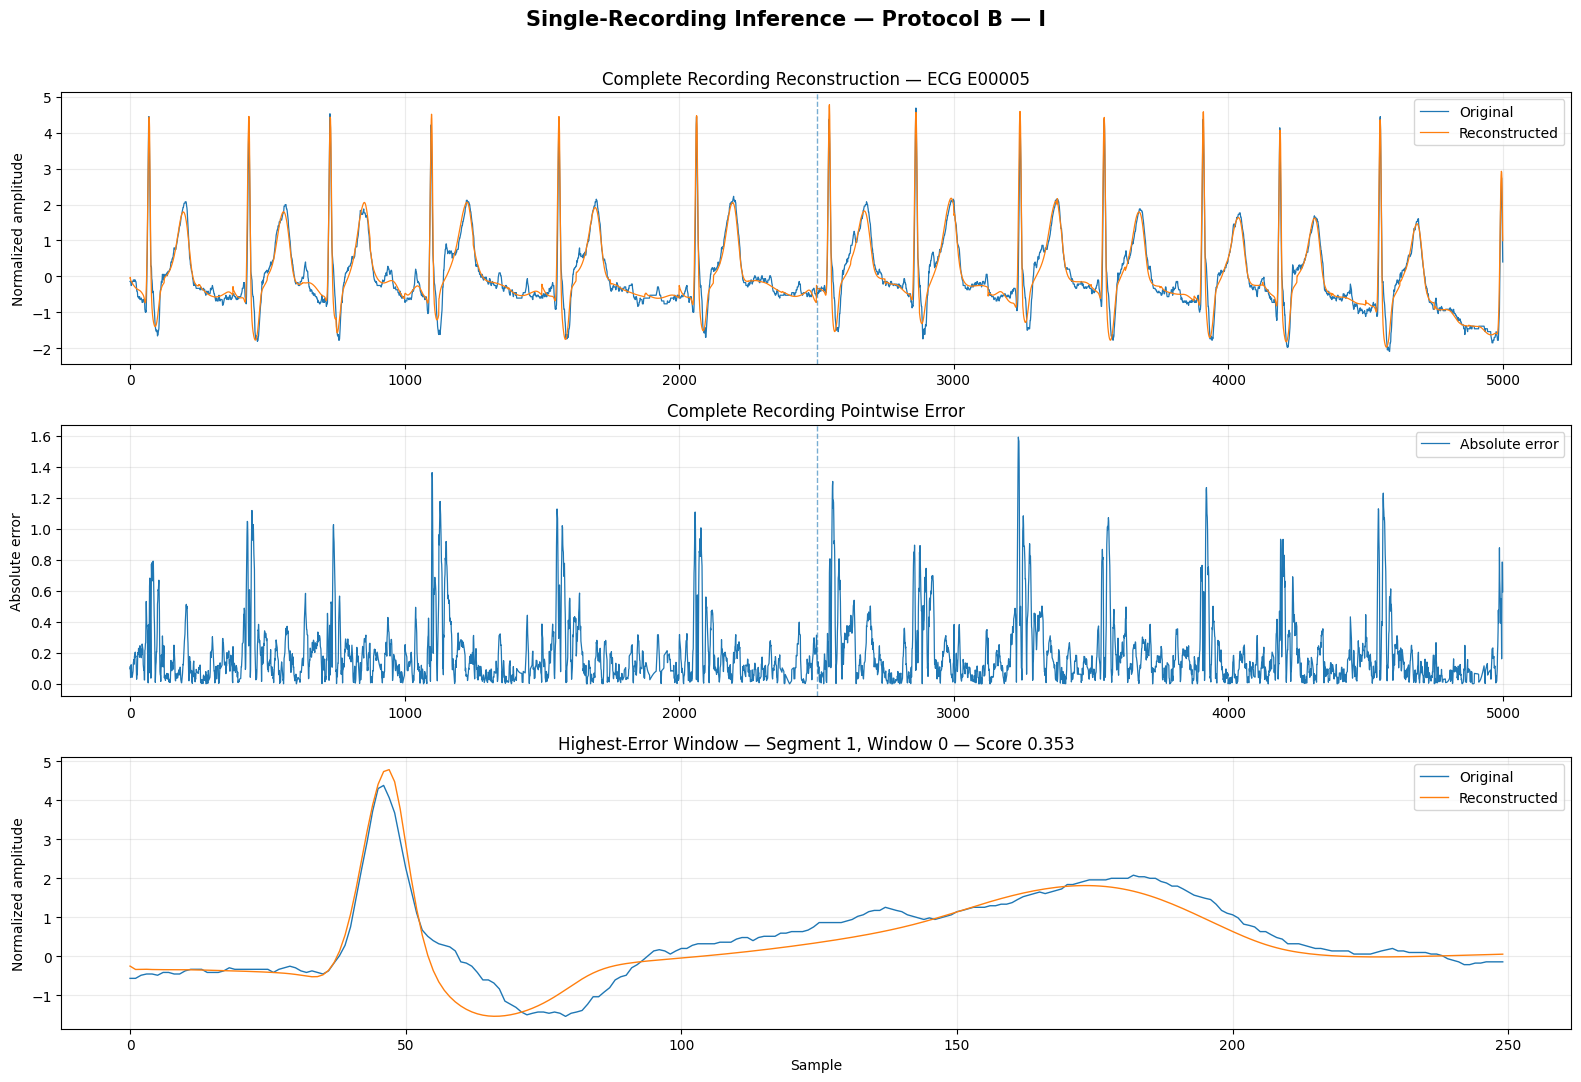

,Protocol,ECG ID,Ground truth,Recording score,Primary threshold,Primary prediction,F1 threshold,F1 prediction,Prediction correct,Segments,Windows,Highest window score
0,B,E00005,AF,0.278659,0.307567,Normal,0.173709,Anomalous,False,2,38,0.353046


,Segment,Windows,Length,Aggregated score,Full-segment MAE,Full-segment MSE,Output/input std ratio
0,0,19,2500,0.247781,0.216748,0.124948,0.892175
1,1,19,2500,0.278659,0.247626,0.160184,0.888454


Unified inference completed for ECG E00005. The recomputed recording score matched the saved test result.


In [24]:
# ==========================================================
# 12.11 Unified Single-Recording Inference
# ==========================================================
# Run the complete anomaly-detection pipeline for one test
# recording using the better-ranked protocol.

INFERENCE_PROTOCOL = QUALITATIVE_PROTOCOL
RECORDING_INDEX = 0
DISPLAY_LEAD = 0

if not 0 <= DISPLAY_LEAD < N_LEADS:
    raise ValueError("DISPLAY_LEAD is outside the valid lead range.")

protocol = INFERENCE_PROTOCOL
data = protocol_data[protocol]
model = evaluation_models[protocol]["model"]

aggregation = aggregation_results[protocol]["configuration"]
thresholds = threshold_results[protocol]

test_predictions = data["test_predictions"]
test_windows = data["test_lstm_df"]

recording_ids = test_predictions["ecg_id"].drop_duplicates().reset_index(
    drop=True
)

if not 0 <= RECORDING_INDEX < len(recording_ids):
    raise IndexError("RECORDING_INDEX is outside the test-set range.")

ecg_id = recording_ids.iloc[RECORDING_INDEX]

saved_result = test_predictions.loc[
    test_predictions["ecg_id"].eq(ecg_id)
].iloc[0]

recording_windows = (
    test_windows.loc[test_windows["ecg_id"].eq(ecg_id)]
    .sort_values(["segment_id", "window_id"])
    .reset_index(drop=True)
)

if recording_windows.empty:
    raise ValueError(f"No windows found for ECG {ecg_id}.")


# ----------------------------------------------------------
# Reconstruct all windows in one forward pass
# ----------------------------------------------------------
original_tensor = torch.from_numpy(
    np.stack(recording_windows["ecg"].to_numpy())
).to(
    DEVICE,
    dtype=torch.float32,
)

model.eval()

with torch.inference_mode():
    reconstructed_tensor = model(original_tensor)

if reconstructed_tensor.shape != original_tensor.shape:
    raise RuntimeError("Input and reconstruction shapes do not match.")

if not torch.isfinite(reconstructed_tensor).all():
    raise RuntimeError("The reconstruction contains NaN or Inf.")

original_windows = original_tensor.cpu().numpy()
reconstructed_windows = reconstructed_tensor.cpu().numpy()


# ----------------------------------------------------------
# Recompute window, segment, and recording scores
# ----------------------------------------------------------
score_tensors = compute_window_scores(
    original_tensor,
    reconstructed_tensor,
)

window_scores = recording_windows[
    [
        "ecg_id",
        "segment_id",
        "AF",
        "window_id",
        "start_sample",
        "end_sample",
    ]
].copy()

for score_name, values in score_tensors.items():
    window_scores[score_name] = values.cpu().numpy()

segment_scores, recording_scores = build_recording_scores(
    window_df=window_scores,
    score_name=aggregation["score_name"],
    window_to_segment=aggregation["window_to_segment"],
    segment_to_recording=aggregation["segment_to_recording"],
)

recording_score = float(recording_scores["recording_score"].iloc[0])
saved_score = float(saved_result["recording_score"])

if not np.isclose(
    recording_score,
    saved_score,
    rtol=1e-5,
    atol=1e-7,
):
    raise RuntimeError(
        "The independently recomputed score does not match "
        "the saved test result."
    )

primary_threshold = thresholds["primary_threshold"]
f1_threshold = thresholds["f1_threshold"]

primary_prediction = int(recording_score >= primary_threshold)
f1_prediction = int(recording_score >= f1_threshold)
ground_truth = int(saved_result["AF"])

if primary_prediction != int(saved_result["prediction_primary"]):
    raise RuntimeError("The recomputed primary prediction does not match.")


# ----------------------------------------------------------
# Rebuild complete segments using overlap averaging
# ----------------------------------------------------------
segment_originals = []
segment_reconstructions = []
segment_summary_rows = []

for segment_id in recording_windows["segment_id"].drop_duplicates():
    mask = recording_windows["segment_id"].eq(segment_id).to_numpy()
    positions = np.flatnonzero(mask)

    rows = (
        recording_windows.loc[mask]
        .sort_values("window_id")
        .reset_index(drop=True)
    )

    segment_length = int(rows["end_sample"].max())

    original_sum = np.zeros(
        (segment_length, N_LEADS),
        dtype=np.float64,
    )
    reconstructed_sum = np.zeros_like(original_sum)
    counts = np.zeros(segment_length, dtype=np.float64)

    for local_index, row in rows.iterrows():
        start = int(row["start_sample"])
        end = int(row["end_sample"])
        position = positions[local_index]

        original_sum[start:end] += original_windows[position]
        reconstructed_sum[start:end] += reconstructed_windows[position]
        counts[start:end] += 1

    if (counts == 0).any():
        raise RuntimeError(
            f"Segment {segment_id} contains uncovered samples."
        )

    original_segment = (
        original_sum / counts[:, None]
    ).astype(np.float32)

    reconstructed_segment = (
        reconstructed_sum / counts[:, None]
    ).astype(np.float32)

    difference = reconstructed_segment - original_segment

    segment_originals.append(original_segment)
    segment_reconstructions.append(reconstructed_segment)

    aggregated_score = float(
        segment_scores.loc[
            segment_scores["segment_id"].eq(segment_id),
            "segment_score",
        ].iloc[0]
    )

    input_std = float(original_segment.std())
    output_std = float(reconstructed_segment.std())

    segment_summary_rows.append({
        "Segment": segment_id,
        "Windows": len(rows),
        "Length": len(original_segment),
        "Aggregated score": aggregated_score,
        "Full-segment MAE": float(np.abs(difference).mean()),
        "Full-segment MSE": float(np.square(difference).mean()),
        "Output/input std ratio": (
            output_std / max(input_std, 1e-8)
        ),
    })


recording_original = np.concatenate(segment_originals, axis=0)
recording_reconstructed = np.concatenate(
    segment_reconstructions,
    axis=0,
)
recording_error = np.abs(
    recording_original - recording_reconstructed
)

segment_boundaries = np.cumsum(
    [len(segment) for segment in segment_originals]
)

segment_summary = pd.DataFrame(segment_summary_rows)


# ----------------------------------------------------------
# Identify the highest-error window
# ----------------------------------------------------------
selected_score = aggregation["score_name"]
selected_window_scores = window_scores[selected_score].to_numpy()

highest_position = int(np.argmax(selected_window_scores))
highest_metadata = window_scores.iloc[highest_position]

highest_original = original_windows[highest_position]
highest_reconstructed = reconstructed_windows[highest_position]


# ----------------------------------------------------------
# Unified inference figure
# ----------------------------------------------------------
lead_name = LEAD_NAMES[DISPLAY_LEAD]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 11),
)

# Complete recording reconstruction
axes[0].plot(
    recording_original[:, DISPLAY_LEAD],
    linewidth=0.9,
    label="Original",
)
axes[0].plot(
    recording_reconstructed[:, DISPLAY_LEAD],
    linewidth=0.9,
    label="Reconstructed",
)

for boundary in segment_boundaries[:-1]:
    axes[0].axvline(
        boundary,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

axes[0].set_title(
    f"Complete Recording Reconstruction — ECG {ecg_id}"
)
axes[0].set_ylabel("Normalized amplitude")
axes[0].legend()
axes[0].grid(alpha=0.25)

# Complete recording error
axes[1].plot(
    recording_error[:, DISPLAY_LEAD],
    linewidth=0.9,
    label="Absolute error",
)

for boundary in segment_boundaries[:-1]:
    axes[1].axvline(
        boundary,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

axes[1].set_title("Complete Recording Pointwise Error")
axes[1].set_ylabel("Absolute error")
axes[1].legend()
axes[1].grid(alpha=0.25)

# Highest-error window
axes[2].plot(
    highest_original[:, DISPLAY_LEAD],
    linewidth=1,
    label="Original",
)
axes[2].plot(
    highest_reconstructed[:, DISPLAY_LEAD],
    linewidth=1,
    label="Reconstructed",
)

axes[2].set_title(
    f"Highest-Error Window — Segment "
    f"{highest_metadata['segment_id']}, "
    f"Window {highest_metadata['window_id']} — "
    f"Score {selected_window_scores[highest_position]:.3f}"
)
axes[2].set_xlabel("Sample")
axes[2].set_ylabel("Normalized amplitude")
axes[2].legend()
axes[2].grid(alpha=0.25)

fig.suptitle(
    f"Single-Recording Inference — Protocol {protocol} — "
    f"{lead_name}",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.97])


# ----------------------------------------------------------
# Save outputs
# ----------------------------------------------------------
output_dir = (
    OUTPUT_ROOT
    / f"protocol_{protocol}"
    / "single_recording_inference"
)
figure_dir = (
    OUTPUT_ROOT
    / f"protocol_{protocol}"
    / "figures"
    / "single_recording_inference"
)

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

figure_path = (
    figure_dir
    / f"protocol_{protocol}_{ecg_id}_unified_inference.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

window_scores.to_csv(
    output_dir
    / f"protocol_{protocol}_{ecg_id}_window_scores.csv",
    index=False,
)

segment_scores.to_csv(
    output_dir
    / f"protocol_{protocol}_{ecg_id}_segment_scores.csv",
    index=False,
)

segment_summary.to_csv(
    output_dir
    / f"protocol_{protocol}_{ecg_id}_segment_summary.csv",
    index=False,
)

recording_summary = pd.DataFrame([{
    "Protocol": protocol,
    "ECG ID": ecg_id,
    "Ground truth": "AF" if ground_truth else "Normal",
    "Recording score": recording_score,
    "Primary threshold": primary_threshold,
    "Primary prediction": (
        "Anomalous" if primary_prediction else "Normal"
    ),
    "F1 threshold": f1_threshold,
    "F1 prediction": (
        "Anomalous" if f1_prediction else "Normal"
    ),
    "Prediction correct": primary_prediction == ground_truth,
    "Segments": len(segment_originals),
    "Windows": len(recording_windows),
    "Highest window score": float(
        selected_window_scores[highest_position]
    ),
}])

recording_summary.to_csv(
    output_dir
    / f"protocol_{protocol}_{ecg_id}_recording_summary.csv",
    index=False,
)


# ----------------------------------------------------------
# Concise inference report
# ----------------------------------------------------------
display(recording_summary.round(6))
display(segment_summary.round(6))

print(
    f"Unified inference completed for ECG {ecg_id}. "
    f"The recomputed recording score matched the saved test result."
)

# 12.12 Final Protocol Comparison (Protocol A vs Protocol B)

In [28]:
# ==========================================================
# 12.12 Final Protocol Comparison
# ==========================================================
# Build a metric-oriented summary from results already
# produced by the previous training and evaluation sections.

required_objects = [
    "RUN_PROTOCOLS",
    "protocol_data",
    "evaluation_models",
    "aggregation_results",
    "threshold_results",
    "evaluation_results",
    "OUTPUT_ROOT",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run the preceding sections first. Missing objects: "
        f"{missing_objects}"
    )

if set(RUN_PROTOCOLS) != {"A", "B"}:
    raise ValueError(
        "RUN_PROTOCOLS must contain Protocol A and Protocol B."
    )


# ----------------------------------------------------------
# Collect previously computed results
# ----------------------------------------------------------
protocol_summary = {}

for protocol in RUN_PROTOCOLS:
    data = protocol_data[protocol]
    checkpoint = evaluation_models[protocol]["checkpoint"]
    aggregation = aggregation_results[protocol]["configuration"]
    thresholds = threshold_results[protocol]
    evaluation = evaluation_results[protocol]

    train_labels = data["train_labels"]
    class_counts = train_labels["AF"].value_counts()

    primary = evaluation["primary"]
    f1_metrics = evaluation["f1_optimized"]

    protocol_summary[protocol] = {
        "Training strategy": (
            "Normal only"
            if int(class_counts.get(1, 0)) == 0
            else "Normal + AF"
        ),
        "Training recordings": int(len(train_labels)),
        "Training windows": int(len(data["train_dataset"])),
        "Best epoch": int(checkpoint["epoch"]),
        "Best validation loss": float(
            checkpoint["validation_loss"]
        ),
        "Validation ROC-AUC": float(
            aggregation["validation_roc_auc"]
        ),
        "Validation PR-AUC": float(
            aggregation["validation_pr_auc"]
        ),
        "Recording score": aggregation["score_name"].upper(),
        "Aggregation strategy": (
            f"{aggregation['window_to_segment']} → "
            f"{aggregation['segment_to_recording']}"
        ),
        "Primary threshold": float(
            thresholds["primary_threshold"]
        ),
        "Test ROC-AUC": float(evaluation["roc_auc"]),
        "Test PR-AUC": float(evaluation["pr_auc"]),
        "Balanced accuracy (Primary)": float(
            primary["Balanced accuracy"]
        ),
        "Sensitivity (Primary)": float(
            primary["Recall / sensitivity"]
        ),
        "Specificity (Primary)": float(
            primary["Specificity"]
        ),
        "F1-score (Primary)": float(
            primary["F1-score"]
        ),
        "Balanced accuracy (F1)": float(
            f1_metrics["Balanced accuracy"]
        ),
        "Sensitivity (F1)": float(
            f1_metrics["Recall / sensitivity"]
        ),
        "Specificity (F1)": float(
            f1_metrics["Specificity"]
        ),
        "F1-score (F1)": float(
            f1_metrics["F1-score"]
        ),
    }


# ----------------------------------------------------------
# Metrics for which a better value is meaningful
# ----------------------------------------------------------
comparison_rules = {
    "Best validation loss": "lower",
    "Validation ROC-AUC": "higher",
    "Validation PR-AUC": "higher",
    "Test ROC-AUC": "higher",
    "Test PR-AUC": "higher",
    "Balanced accuracy (Primary)": "higher",
    "Sensitivity (Primary)": "higher",
    "Specificity (Primary)": "higher",
    "F1-score (Primary)": "higher",
    "Balanced accuracy (F1)": "higher",
    "Sensitivity (F1)": "higher",
    "Specificity (F1)": "higher",
    "F1-score (F1)": "higher",
}


def compare_metric(metric, value_a, value_b):
    """Return the better protocol only when comparison is meaningful."""
    rule = comparison_rules.get(metric)

    if rule is None:
        return "Same" if value_a == value_b else "N/A"

    if np.isclose(value_a, value_b, rtol=1e-6, atol=1e-8):
        return "Same"

    if rule == "lower":
        return "Protocol A" if value_a < value_b else "Protocol B"

    return "Protocol A" if value_a > value_b else "Protocol B"


# ----------------------------------------------------------
# Create metric-oriented comparison table
# ----------------------------------------------------------
comparison_rows = []

for metric in protocol_summary["A"]:
    value_a = protocol_summary["A"][metric]
    value_b = protocol_summary["B"][metric]

    comparison_rows.append({
        "Metric": metric,
        "Protocol A": value_a,
        "Protocol B": value_b,
        "Better": compare_metric(metric, value_a, value_b),
    })

final_protocol_comparison = pd.DataFrame(comparison_rows)


# ----------------------------------------------------------
# Format only the displayed table
# ----------------------------------------------------------
def format_value(value):
    if isinstance(value, (float, np.floating)):
        return f"{value:.4f}"

    if isinstance(value, (int, np.integer)):
        return f"{value:,}"

    return str(value)


display_table = final_protocol_comparison.copy()

for column in ["Protocol A", "Protocol B"]:
    display_table[column] = display_table[column].map(format_value)

display(display_table)


# ----------------------------------------------------------
# Select the final model using threshold-independent metrics
# ----------------------------------------------------------
best_protocol = max(
    RUN_PROTOCOLS,
    key=lambda protocol: (
        evaluation_results[protocol]["roc_auc"],
        evaluation_results[protocol]["pr_auc"],
    ),
)

best_summary = protocol_summary[best_protocol]


# ----------------------------------------------------------
# Save raw comparison values
# ----------------------------------------------------------
comparison_path = OUTPUT_ROOT / "final_protocol_comparison.csv"

final_protocol_comparison.to_csv(
    comparison_path,
    index=False,
)


# ----------------------------------------------------------
# Final interpretation
# ----------------------------------------------------------
print("=" * 80)
print("FINAL EXPERIMENTAL INTERPRETATION")
print("=" * 80)

print(
    f"Protocol {best_protocol} achieved the strongest overall "
    "recording-level discrimination."
)

print(
    f"Test ROC-AUC       : {best_summary['Test ROC-AUC']:.4f}\n"
    f"Test PR-AUC        : {best_summary['Test PR-AUC']:.4f}\n"
    f"Balanced accuracy  : "
    f"{best_summary['Balanced accuracy (F1)']:.4f}\n"
    f"F1-score           : {best_summary['F1-score (F1)']:.4f}"
)

print(
    "\nThe final protocol is selected using test ROC-AUC, "
    "with PR-AUC used as a tie-breaker. Threshold-dependent "
    "sensitivity and specificity are reported as operating-point "
    "characteristics rather than independent model-selection criteria."
)

print(f"\n✓ Selected final model: Protocol {best_protocol}")
print(f"✓ Comparison saved to: {comparison_path}")

,Metric,Protocol A,Protocol B,Better
0,Training strategy,Normal + AF,Normal only,N/A
1,Training recordings,"1,068","2,340",N/A
2,Training windows,"40,451","88,635",N/A
3,Best epoch,50,50,Same
4,Best validation loss,0.1185,0.0938,Protocol B
5,Validation ROC-AUC,0.6569,0.6827,Protocol B
6,Validation PR-AUC,0.6399,0.6691,Protocol B
7,Recording score,MAE,MAE,Same
8,Aggregation strategy,median → max,median → max,Same
9,Primary threshold,0.3392,0.3076,N/A


FINAL EXPERIMENTAL INTERPRETATION
Protocol B achieved the strongest overall recording-level discrimination.
Test ROC-AUC       : 0.6851
Test PR-AUC        : 0.6138
Balanced accuracy  : 0.6513
F1-score           : 0.7225

The final protocol is selected using test ROC-AUC, with PR-AUC used as a tie-breaker. Threshold-dependent sensitivity and specificity are reported as operating-point characteristics rather than independent model-selection criteria.

✓ Selected final model: Protocol B
✓ Comparison saved to: /kaggle/working/outputs/final_protocol_comparison.csv
